# 최근접 이웃(K-Nearest Neighbor)

*   특별한 예측 모델 없이 가장 가까운 데이터 포인트를 기반으로 예측을 수행하는 방법
*   분류와 회귀 모두 지원

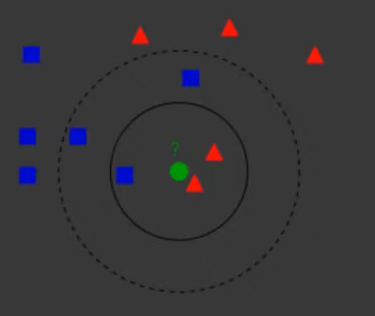

In [ ]:
### 라이브러리 임포트 및 설정

import pandas as pd           # 데이터판다스: 표 형태의 데이터를 다루는 데 최적화된 라이브러리 (DataFrame 사용)
import numpy as np            # 넘파이: 고성능 수치 계산 및 다차원 배열 처리를 위한 필수 라이브러리
import multiprocessing       # 멀티프로세싱: CPU의 여러 코어를 동시에 사용하여 연산 속도를 높일 때 사용
import matplotlib.pyplot as plt # 맷플롯립: 파이썬의 가장 기본적인 그래프 시각화 도구
import seaborn as sns         # 시본: matplotlib을 기반으로 더 예쁘고 통계적인 그래프를 그려주는 라이브러리 # seaborn import 추가

# 시각화 스타일 설정
# plt.style.use(['seaborn-whitegrid']) -> 구버전 코드 혹은 대체 가능한 방식
# matplotlib.pyplot.style.use 대신 sns.set_style 사용
sns.set_style('whitegrid')    # 그래프의 배경에 격자(grid)를 추가하여 데이터의 수치를 보기 편하게 설정

In [ ]:
### 머신러닝 모델 및 도구 임포트
### scikit-learn에서 모델 구축, 데이터 전처리, 성능 검증에 필요한 기능을 가져옵니다.

# K-최근접 이웃(KNN) 알고리즘: 분류용(Classifier)과 회귀용(Regressor) 모델을 가져옴
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
# T-SNE: 고차원 데이터를 2~3차원으로 축소하여 시각화할 때 사용하는 차원 축소 알고리즘
from sklearn.manifold import TSNE
# 연습용 데이터셋들 (붓꽃, 유방암, 와인 데이터)
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
# 캘리포니아 주택 가격 데이터셋 (회귀 분석용)
from sklearn.datasets import fetch_california_housing
#from sklearn.datasets import load_boston, fetch_california_housing

# 외부 파일에서 데이터 읽기
boston_df = pd.read_csv("boston.csv")  # 로컬에 저장된 "boston.csv" 파일을 읽어 판다스 데이터프레임으로 변환

# 모델 검증 및 최적화 도구
# train_test_split: 학습용과 테스트용 데이터 분리
# cross_validate: 교차 검증을 통해 모델의 일반화 성능 측정
# GridSearchCV: 하이퍼파라미터(모델 설정값) 후보군 중 최적의 조합을 자동 탐색
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

# 데이터 전처리 도구
from sklearn.preprocessing import StandardScaler      # 표준화: 데이터의 평균을 0, 표준편차를 1로 변환 (KNN은 거리 기반이라 필수)
from sklearn.pipeline import make_pipeline, Pipeline  # 파이프라인: 전처리와 모델 학습 과정을 하나로 묶어 관리하는 도구

# K 최근접 이웃 분류

*   입력 데이터 포인트와 가장 가까운 k개의 훈련 데이터 포인트가 출력
*   k개의 데이터 포인트 중 가장 많은 클래스가 예측 결과

# 붓꽃 데이터

In [ ]:
### 데이터 로드 및 데이터프레임 생성
### 가장 유명한 예제인 '붓꽃(Iris)' 데이터를 실제로 불러와 분석하기 좋은 형태로 만듭니다.

# 1. 붓꽃 데이터셋 로드 (딕셔너리와 유사한 Bunch 객체 형태)
iris = load_iris()

In [ ]:
### 데이터 로드 및 데이터프레임 생성
### 가장 유명한 예제인 '붓꽃(Iris)' 데이터를 실제로 불러와 분석하기 좋은 형태로 만듭니다.

# 2. 독립 변수(특성) 데이터프레임 생성
# iris.data: 꽃잎의 길이/너비 등 수치 데이터
# iris.feature_names: 각 수치 데이터의 열 이름 (sepal length 등)
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 3. 종속 변수(정답/타겟) 열 추가
# iris.target: 0, 1, 2로 분류된 붓꽃의 종류
iris_df['Target'] = iris.target

# 4. 생성된 데이터프레임 확인
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


타깃 분류는 0,1,2 세가지로 나눠진다.

In [ ]:
### 데이터 분할
### 학습 및 테스트 데이터 분할 : 모델의 성능을 공정하게 평가하기 위해 데이터를 나눕니다.

# return_X_y=True: 원본 객체 전체가 아닌 특성(X)과 정답(y) 데이터만 튜플 형태로 바로 반환받음
X, y = load_iris(return_X_y=True)

# 데이터를 학습용(Train)과 검증용(Test)으로 나눔
# X_train, y_train: 모델이 공부할 때 사용할 데이터
# X_test, y_test: 모델이 공부를 마친 후 실력을 시험해볼 미지의 데이터
# test_size=0.2: 전체 데이터 중 20%를 테스트용으로 할당 (나머지 80%는 학습용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### 데이터 표준화 (StandardScaler) :
### KNN 알고리즘은 데이터 간의 거리를 계산하여 분류하기 때문에, 변수들의 단위(cm, kg 등-크기)를 통일하는 스케일링이 필수적입니다.

# StandardScaler 객체 생성: 평균을 0, 표준편차를 1로 만드는 표준화를 수행하는 도구입니다.
scaler = StandardScaler()

# fit_transform: 학습 데이터(X_train)의 평균과 표준편차를 계산(fit)하고, 그 값으로 데이터를 변환(transform)합니다.
X_train_scale = scaler.fit_transform(X_train)

# transform: 학습 데이터에서 계산된 평균과 표준편차를 그대로 사용하여 테스트 데이터(X_test)를 변환합니다.
# (주의: 테스트 데이터로 새롭게 fit을 하면 모델이 미래의 데이터를 미리 보는 꼴이 되므로 transform만 사용합니다.)
X_test_scale = scaler.transform(X_test)

In [ ]:
### 기본 모델 학습 (스케일링 전) :
### 데이터를 가공하지 않은 상태에서 KNN 모델을 학습시키는 과정입니다.

# KNeighborsClassifier 객체 생성: 가장 가까운 이웃 k개를 보고 분류하는 모델입니다.
model = KNeighborsClassifier()

# fit: 학습 데이터(X_train)와 정답(y_train)을 모델에 입력하여 데이터 간의 관계를 학습시킵니다.
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
### 기본 모델 성능 평가 :
### 학습된 모델이 얼마나 잘 맞추는지 정확도(Accuracy)를 출력합니다.

# score: 모델의 성능(분류의 경우 정확도)을 측정합니다. 1.0에 가까울수록 완벽한 모델입니다.
# 학습 데이터에 대한 점수를 출력 (모델이 얼마나 데이터를 잘 외웠는지 확인)
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))

# 테스트 데이터에 대한 점수를 출력 (실전에서 얼마나 잘 맞출지 확인)
print("테스트 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9666666666666667
테스트 데이터 점수: 0.9666666666666667


In [ ]:
### 스케일링된 데이터로 모델 학습 :
### 전처리가 완료된 데이터를 사용하여 다시 모델을 학습시킵니다. 보통 이 단계에서 성능이 향상됩니다.

# 새로운 KNN 모델 객체 생성
model = KNeighborsClassifier()

# fit: 표준화된 학습 데이터(X_train_scale)를 사용하여 모델을 학습시킵니다.
# 거리 기반 알고리즘인 KNN은 이 과정에서 각 특성의 영향력이 균등해져 성능이 안정화됩니다.
model.fit(X_train_scale, y_train)

KNeighborsClassifier()

In [ ]:
### 스케일링 후 성능 평가 :
### 스케일링된 데이터를 넣었을 때의 결과를 확인합니다.

# 표준화된 학습 데이터로 점수 측정
# 1. 학습 데이터에 대한 모델의 성능(정확도)을 측정합니다.
# model.score(X, y): 학습된 모델에 입력값(X)을 넣어 예측값을 얻은 뒤, 실제 정답(y)과 비교하여 맞춘 비율(0~1)을 반환합니다.
# X_train_scale: 이미 평균 0, 표준편차 1로 스케일링된 학습용 데이터입니다.
# 의미: 모델이 학습 데이터를 얼마나 잘 '학습(또는 암기)'했는지 확인하는 용도입니다.
print("학습 데이터 점수: {}".format(model.score(X_train_scale, y_train)))

# 2. 테스트 데이터(보지 못한 데이터)에 대한 모델의 성능을 측정합니다.
# X_test_scale: 학습 데이터의 기준(평균, 표준편차)에 맞춰 동일하게 변형된 테스트용 데이터입니다.
# y_test: 테스트 데이터에 대한 실제 정답지입니다.
# 의미: 모델의 '일반화 성능'을 확인하는 가장 중요한 단계입니다.
# 학습 데이터 점수와 차이가 크지 않으면서 높은 점수가 나와야 좋은 모델이라고 평가합니다.
print("테스트 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

# [주의] 테스트 데이터도 반드시 표준화된 데이터(X_test_scale)를 넣어야 합니다.
# 원본 코드의 (X_test, y_test)는 스케일링되지 않은 값이라 오류나 낮은 점수가 나올 수 있습니다.
# 올바른 코드: print("테스트 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

학습 데이터 점수: 0.9583333333333334
테스트 데이터 점수: 0.9333333333333333


iris 데이터 셋은 이미 잘 분류되는 포인트 위치를 가지고 있어서 scaler를 하지 않은 상태가 더 평가점수가 높다.

In [ ]:
### 교차 검증 (Cross Validation) :
### 데이터를 여러 조각으로 나누어 반복 학습시키고, 모델의 평균적인 성능을 측정합니다.

cross_validate(
    estimator=KNeighborsClassifier(), # 평가할 모델 객체를 지정합니다. (여기서는 KNN 분류기)
    X=X, y=y,                        # 전체 독립변수(X)와 종속변수(y)를 입력합니다.
    cv=5,                             # 데이터를 5개 그룹으로 나누어 5번 반복 검증합니다. (5-Fold CV)
    n_jobs=multiprocessing.cpu_count(), # 컴퓨터의 모든 CPU 코어를 사용하여 연산 속도를 최대화합니다.
    verbose=True                      # 모델 학습 진행 과정을 화면에 출력하여 상태를 확인합니다.
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:    3.9s finished


{'fit_time': array([0.00211573, 0.00226045, 0.00892711, 0.00316215, 0.00271964]),
 'score_time': array([0.00447941, 0.00586939, 0.00579476, 0.01182866, 0.01197577]),
 'test_score': array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])}

테스트 점수가 매우 높게 나옴을 확인 가능

In [ ]:
### 하이퍼파라미터 후보 설정 (Param Grid) :
### 모델의 성능에 영향을 주는 여러 설정값(옵션)들을 조합하여 최적의 값을 찾기 위한 '후보 리스트'를 만듭니다.

param_grid = [{
    'n_neighbors': [3, 5, 7],         # 이웃의 개수를 3, 5, 7개 중 무엇으로 할지 결정합니다.
    'weights': ['uniform', 'distance'], # 가중치 부여 방식 (단순 평균 vs 거리에 따른 차등)
    'algorithm': ['ball_tree', 'kd_tree', 'brute'] # 가장 가까운 이웃을 찾는 알고리즘 방식들입니다.
}]

# ball_tree (볼 트리): 데이터를 다차원 구(Ball) 형태의 계층 구조로 나누어 저장하며, 차원이 매우 높고 데이터가 복잡하게 퍼져 있을 때 kd_tree보다 효율적입니다.
# kd_tree (K-D 트리): 데이터를 각 축(특성)을 기준으로 이진 분할하여 공간을 나누는 방식이며, 데이터의 차원(Feature 수)이 낮을 때 매우 빠르게 이웃을 찾습니다.
# brute (브루트 포스): '무식하게 풀기'라는 뜻 그대로, 모든 데이터 포인트 사이의 거리를 일일이 계산하는 방식이며 데이터 양이 아주 적을 때만 사용합니다.

# 데이터가 적으면 brute
# 데이터 차원이 낮으면 kd_tree
# 데이터 차원이 높으면 ball_tree가 유리한 경향

In [ ]:
### 그리드 서치(GridSearchCV) 객체 생성 :
### 설정한 모든 후보 조합을 하나씩 대입하여 가장 높은 점수를 내는 조합을 자동으로 찾아주는 도구입니다.

gs = GridSearchCV(
    estimator=KNeighborsClassifier(),  # 최적화를 진행할 대상 모델을 지정합니다.
    param_grid=param_grid,             # 위에서 만든 후보 리스트(param_grid)를 전달합니다.
    n_jobs=multiprocessing.cpu_count(), # 모든 CPU 자원을 투입하여 병렬 연산을 수행합니다.
    verbose=True                       # 탐색 과정을 상세히 출력합니다.
)

In [ ]:
### 모델 학습 및 최적의 결과 확인 :
### 실제로 모든 조합을 테스트해보고 가장 좋은 모델을 골라내는 단계

# 1. 모든 조합(3x2x3 = 18가지)에 대해 교차 검증을 수행하며 학습을 진행합니다.
gs.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=KNeighborsClassifier(), n_jobs=2,
             param_grid=[{'algorithm': ['ball_tree', 'kd_tree', 'brute'],
                          'n_neighbors': [3, 5, 7],
                          'weights': ['uniform', 'distance']}],
             verbose=True)

In [ ]:
### 모델 학습 및 최적의 결과 확인 :
### 실제로 모든 조합을 테스트해보고 가장 좋은 모델을 골라내는 단계

# 2. 모든 조합 중 가장 성능이 좋았던 '베스트 모델 객체'를 반환합니다.
# 어떤 파라미터가 선택되었는지(예: n_neighbors=3 등) 확인할 수 있습니다.
gs.best_estimator_

KNeighborsClassifier(algorithm='ball_tree', n_neighbors=7)

In [ ]:
### 모델 학습 및 최적의 결과 확인 :
### 실제로 모든 조합을 테스트해보고 가장 좋은 모델을 골라내는 단계

# 3. 최적의 파라미터 조합으로 얻은 가장 높은 평균 정확도를 출력합니다.
print('GridSearchCV best score: {}'.format(gs.best_score_))

GridSearchCV best score: 0.9800000000000001


In [ ]:
### 시각화를 위한 보조 함수 정의 :
### 격자 무늬의 배경을 만들고, 모델의 예측 결과를 색상으로 채우는 함수들

# 격자 좌표(Meshgrid) 생성 함수
def make_meshgrid(x, y, h=.02):
  # x와 y의 최소/최대값에서 여유분(1)을 두어 범위를 설정합니다.
  x_min, x_max = x.min()-1, x.max()+1
  y_min, y_max = y.min()-1, y.max()+1
  # np.arange로 h(0.02) 간격의 점들을 만들고, 이를 격자 형태(Matrix)로 변환합니다.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                       np.arange(y_min, y_max, h))
  return xx, yy

# 결정 경계(Contours) 그리기 함수
def plot_contours(clf, xx, yy, **params):
  # 격자점들(xx, yy)을 일렬로 펴서 모델(clf)에 넣고 예측값(Z)을 얻습니다.
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  # 예측된 결과를 다시 격자 모양으로 형태를 바꿉니다.
  Z = Z.reshape(xx.shape)
  # plt.contourf를 이용해 예측 결과에 따라 배경색을 칠합니다.
  out = plt.contourf(xx, yy, Z, **params)
  return out

In [ ]:
### t-SNE를 이용한 차원 축소 :
### 4차원인 붓꽃 데이터를 그래프에 그릴 수 있도록 2차원으로 줄입니다.

# n_components=2: 데이터를 2차원 평면으로 압축하겠다는 설정입니다.
tsne = TSNE(n_components=2)
# fit_transform: 고차원 데이터 X를 유사도를 유지하며 2차원 좌표(X_comp)로 변환합니다.
X_comp = tsne.fit_transform(X)

In [ ]:
### 압축된 데이터 확인 :
### 2차원으로 변한 데이터를 데이터프레임으로 만들어 확인합니다.

# 2차원 좌표 데이터와 정답(y)을 합쳐 데이터프레임을 생성합니다.
iris_comp_df = pd.DataFrame(data=X_comp)
iris_comp_df['Target'] = y
iris_comp_df

,0,1,Target
0,-24.284670,-0.196069,0
1,-21.731905,0.653882,0
2,-21.776773,-0.433848,0
3,-21.413086,-0.141203,0
4,-24.284908,-0.606254,0
...,...,...,...
145,14.369648,-2.493189,2
146,11.872075,-0.541414,2
147,13.772250,-1.774297,2
148,14.138768,-3.394210,2


차원축소 TSNE(n_components=2)에서 n_components를 2로 했으므로 0,1 두개의 피쳐와 타깃값 하나로 나온다.

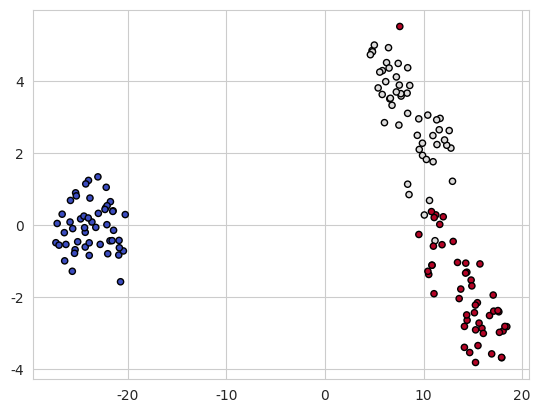

In [ ]:
### 압축된 데이터 시각화 :
### 2차원으로 변한 데이터를 점으로 찍어봅니다.

# 산점도(Scatter plot) 그리기 # 축소된 2차원 좌표 데이터(X_comp)를 산점도로 그림
# X_comp의 0번 열을 x축, 1번 열을 y축으로 설정합니다.
# c=y: 정답 클래스에 따라 색상을 다르게 표현합니다.(종류별 색상)
# cmap(색상 테마), s=20(점 크기), edgecolor='k'(점 테두리 검정색) 설정
plt.scatter(X_comp[:, 0], X_comp[:, 1],
            c=y, cmap=plt.cm.coolwarm, s=20, edgecolor='k')

In [ ]:
### 모델 학습 및 예측 :
### 축소된 2차원 데이터를 바탕으로 KNN 모델을 다시 학습시킵니다.

# 2차원 전용 KNN 모델 생성 및 학습
model = KNeighborsClassifier()
model.fit(X_comp, y)

# 학습된 모델로 전체 데이터에 대한 예측값을 뽑아봅니다.
predict = model.predict(X_comp)

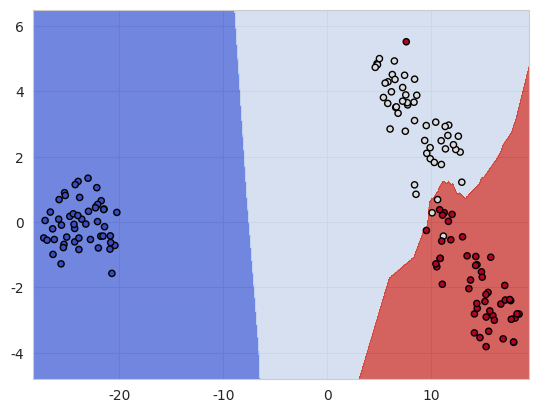

In [ ]:
### 결정 경계(Decision Boundary) 최종 시각화 :
### 모델이 "여기까지는 A종, 저기부터는 B종"이라고 판단하는 영역을 배경으로 그립니다.

# 1. 시각화 범위 설정을 위해 격자 좌표를 만듭니다.
xx, yy = make_meshgrid(X_comp[:, 0], X_comp[:, 1])

# 2. 결정 경계를 그립니다 (배경에 영역별 색상을 칠함).
# alpha=0.8: 배경색을 약간 투명하게 설정하여 점들이 잘 보이게 합니다.
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

# 3. 그 위에 실제 데이터 포인트(점)들을 겹쳐서 그립니다.
plt.scatter(X_comp[:, 0], X_comp[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 유방암 데이터_01

In [ ]:
### 유방암 데이터셋 로드

# 사이킷런에서 제공하는 유방암(Breast Cancer) 진단 데이터셋을 불러와 cancer 변수에 저장합니다.
# 이 데이터는 종양의 크기, 질감 등을 바탕으로 악성(Malignant)인지 양성(Benign)인지 판별하는 용도입니다.
cancer = load_breast_cancer()

In [ ]:
### 전체 데이터프레임 생성 및 확인

# cancer.data(수치 데이터)와 cancer.feature_names(각 열의 이름)를 결합하여 판다스 데이터프레임을 생성합니다.
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

# 'Target'이라는 새로운 열을 만들고, 정답 데이터(0: 악성, 1: 양성)를 할당합니다.
cancer_df['Target'] = cancer.target

# 완성된 전체 데이터프레임을 화면에 출력하여 상단과 하단 데이터를 확인합니다.
cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
### 학습 및 테스트 데이터 분할

# 모델 학습에 사용할 독립 변수(X, 특징들)와 종속 변(y, 정답)를 각각 변수에 할당합니다.
X, y = cancer.data, cancer.target

# train_test_split 함수를 사용하여 데이터를 나눕니다.
# test_size=0.2: 전체 데이터의 20%를 모델 평가를 위한 테스트용으로, 80%를 학습용으로 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### 학습용(Train) 데이터프레임 확인

# 모델이 공부하게 될 '학습용' 특징 데이터를 데이터프레임으로 변환합니다.
cancer_train_df = pd.DataFrame(data=X_train, columns=cancer.feature_names)

# 학습용 정답 데이터(y_train)를 'Target' 열로 추가하여 데이터와 정답이 잘 매칭되었는지 확인합니다.
cancer_train_df['Target'] = y_train

# 학습용으로 분리된 데이터셋(전체의 80%)을 출력하여 확인합니다.
cancer_train_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,18.050,16.15,120.20,1006.0,0.10650,0.21460,0.16840,0.10800,0.2152,0.06673,...,18.91,150.10,1610.0,0.14780,0.5634,0.37860,0.21020,0.3751,0.11080,0
1,13.280,13.72,85.79,541.8,0.08363,0.08575,0.05077,0.02864,0.1617,0.05594,...,17.37,96.59,623.7,0.11660,0.2685,0.28660,0.09173,0.2736,0.07320,1
2,13.870,16.21,88.52,593.7,0.08743,0.05492,0.01502,0.02088,0.1424,0.05883,...,25.58,96.74,694.4,0.11530,0.1008,0.05285,0.05556,0.2362,0.07113,1
3,14.480,21.46,94.25,648.2,0.09444,0.09947,0.12040,0.04938,0.2075,0.05636,...,29.25,108.40,808.9,0.13060,0.1976,0.33490,0.12250,0.3020,0.06846,0
4,15.120,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,20.24,117.70,989.5,0.14910,0.3331,0.33270,0.12520,0.3415,0.09740,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,12.800,17.46,83.05,508.3,0.08044,0.08895,0.07390,0.04083,0.1574,0.05750,...,21.06,90.72,591.0,0.09534,0.1812,0.19010,0.08296,0.1988,0.07053,1
451,15.080,25.74,98.00,716.6,0.10240,0.09769,0.12350,0.06553,0.1647,0.06464,...,33.22,121.20,1050.0,0.16600,0.2356,0.40290,0.15260,0.2654,0.09438,0
452,11.850,17.46,75.54,432.7,0.08372,0.05642,0.02688,0.02280,0.1875,0.05715,...,25.75,84.35,517.8,0.13690,0.1758,0.13160,0.09140,0.3101,0.07007,1
453,14.950,17.57,96.85,678.1,0.11670,0.13050,0.15390,0.08624,0.1957,0.06216,...,21.43,121.40,971.4,0.14110,0.2164,0.33550,0.16670,0.3414,0.07147,0


569 rows에서 455 rows로 줄었다. 455개로 훈련시키고 나머지는 테스트에 쓴다.

In [ ]:
### 테스트용(Test) 데이터프레임 확인

# 모델의 실력을 최종 시험할 '테스트용' 특징 데이터를 데이터프레임으로 변환합니다.
cancer_test_df = pd.DataFrame(data=X_test, columns=cancer.feature_names)

# 테스트용 정답 데이터(y_test)를 'Target' 열로 추가합니다. 이는 나중에 모델의 예측값과 비교할 기준이 됩니다.
cancer_test_df['Target'] = y_test

# 테스트용으로 분리된 데이터셋(전체의 20%)을 출력하여 확인합니다.
cancer_test_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,10.88,15.62,70.41,358.9,0.10070,0.10690,0.05115,0.01571,0.1861,0.06837,...,19.35,80.78,433.1,0.1332,0.3898,0.33650,0.07966,0.2581,0.10800,1
1,12.07,13.44,77.83,445.2,0.11000,0.09009,0.03781,0.02798,0.1657,0.06608,...,15.77,86.92,549.9,0.1521,0.1632,0.16220,0.07393,0.2781,0.08052,1
2,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,22.66,119.80,928.8,0.1765,0.4503,0.44290,0.22290,0.3258,0.11910,0
3,8.95,15.76,58.74,245.2,0.09462,0.12430,0.09263,0.02308,0.1305,0.07163,...,17.07,63.34,270.0,0.1179,0.1879,0.15440,0.03846,0.1652,0.07722,1
4,15.06,19.83,100.30,705.6,0.10390,0.15530,0.17000,0.08815,0.1855,0.06284,...,24.23,123.50,1025.0,0.1551,0.4203,0.52030,0.21150,0.2834,0.08234,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,...,27.26,139.90,1403.0,0.1338,0.2117,0.34460,0.14900,0.2341,0.07421,0
110,12.76,13.37,82.29,504.1,0.08794,0.07948,0.04052,0.02548,0.1601,0.06140,...,16.40,92.04,618.8,0.1194,0.2208,0.17690,0.08411,0.2564,0.08253,1
111,13.16,20.54,84.06,538.7,0.07335,0.05275,0.01800,0.01256,0.1713,0.05888,...,28.46,95.29,648.3,0.1118,0.1646,0.07698,0.04195,0.2687,0.07429,1
112,11.27,15.50,73.38,392.0,0.08365,0.11140,0.10070,0.02757,0.1810,0.07252,...,18.93,79.73,450.0,0.1102,0.2809,0.30210,0.08272,0.2157,0.10430,1


114개로 테스트에 쓴다.

In [ ]:
### 데이터 표준화 (StandardScaler) :
### 거리 기반 알고리즘인 KNN의 성능을 높이기 위해 데이터의 단위를 맞추는 필수 전처리 단계

scaler = StandardScaler() # 평균을 0, 표준편차를 1로 변환하는 스케일러 객체를 생성합니다.
X_train_scale = scaler.fit_transform(X_train) # 학습 데이터의 평균/표준편차를 계산(fit)하고 동시에 변환(transform)합니다.
X_test_scale = scaler.transform(X_test) # 학습 데이터에서 구한 기준을 그대로 사용하여 테스트 데이터도 변환합니다.

In [ ]:
### 기본 모델 학습 (스케일링 전) :
### 데이터 가공 없이 원본 상태로 학습.

model = KNeighborsClassifier() # KNN 분류기 모델 객체를 생성합니다.
model.fit(X_train, y_train) # 스케일링되지 않은 원본 학습 데이터로 모델을 학습시킵니다.


KNeighborsClassifier()

In [ ]:
### 기본 모델 평가 (스케일링 전) :
### 데이터 가공 없이 원본 상태로 학습했을 때의 성능을 확인합니다.

# 학습 및 평가 데이터에 대한 정확도(Accuracy)를 측정하여 출력합니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9472527472527472
평가 데이터 점수: 0.9298245614035088


In [ ]:
### 스케일링된 데이터로 학습 :
### 전처리가 끝난 데이터를 사용해서 학습.

model = KNeighborsClassifier() # 새로운 KNN 모델 객체를 생성합니다.
model.fit(X_train_scale, y_train) # 표준화된 학습 데이터(X_train_scale)로 모델을 학습시킵니다.

KNeighborsClassifier()

In [ ]:
### 스케일링된 데이터로 평가 :
### 전처리가 끝난 데이터를 사용했을 때 점수가 얼마나 향상되는지 비교하는 단계

# 표준화된 데이터를 넣어 성능을 측정합니다. (평가 시에도 반드시 X_test_scale을 사용해야 함)
print("학습 데이터 점수: {}".format(model.score(X_train_scale, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

학습 데이터 점수: 0.9846153846153847
평가 데이터 점수: 0.9473684210526315


In [ ]:
### 파이프라인(Pipeline) 구축 :
### 스케일링과 모델 학습을 하나의 공정으로 묶어주는 도구입니다. 데이터 누수를 방지하고 코드를 간결하게 만듭니다.

# 전처리(StandardScaler)와 모델(KNeighborsClassifier)을 순서대로 연결한 파이프라인을 생성합니다.
# 이렇게 묶으면 나중에 fit을 한 번만 호출해도 전처리와 학습이 자동으로 순차 진행됩니다.
estimator = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

In [ ]:
### 파이프라인 기반 교차 검증 (Cross Validation) :
### 데이터를 5개로 나누어 더 공정하게 모델을 평가합니다.

cross_validate(
    estimator=estimator,            # 위에서 만든 '스케일링+KNN' 파이프라인을 검증 대상으로 사용합니다.
    X=X, y=y,                       # 전체 데이터(X, y)를 전달합니다. (파이프라인 안에서 알아서 나눠서 스케일링함)
    cv=5,                            # 데이터를 5조각으로 나누어 총 5번의 검증을 수행합니다.
    n_jobs=multiprocessing.cpu_count(), # 현재 컴퓨터의 사용 가능한 모든 CPU 코어를 동원해 병렬 연산합니다.
    verbose=True                     # 학습이 진행되는 로그(시간 등)를 화면에 상세히 표시합니다.
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:    0.1s finished


{'fit_time': array([0.0087564 , 0.00335479, 0.00526857, 0.00649428, 0.00558376]),
 'score_time': array([0.00962734, 0.00347114, 0.0064466 , 0.00664878, 0.00428247]),
 'test_score': array([0.96491228, 0.95614035, 0.98245614, 0.95614035, 0.96460177])}

cross_validate한 결과는 좋게 나옴.

In [ ]:
### 파이프라인(Pipeline) 구축 :
### 데이터 전처리와 모델 학습 과정을 하나로 묶는 단계입니다. 데이터 누수를 방지하고 코드를 깔끔하게 관리할 수 있게 해줍니다.

# 여러 단계의 처리 과정을 하나로 묶어주는 Pipeline 객체를 생성합니다.
pipe = Pipeline(
    [
        # 1단계: 데이터의 평균을 0, 표준편차를 1로 맞추는 표준화(StandardScaler)를 수행합니다.
        # KNN은 거리 기반 알고리즘이라 변수 간 스케일을 맞추는 것이 필수적입니다.
        ('scaler', StandardScaler()),

        # 2단계: 최상위 모델로 K-최근접 이웃(K-Neighbors Classifier) 분류기를 설정합니다.
        ('model', KNeighborsClassifier())
    ]
)

In [ ]:
### 하이퍼파라미터 그리드(Param Grid) 설정 :
### 모델의 성능을 결정하는 변수들을 어떤 범위 내에서 탐색할지 지정합니다.

# GridSearchCV가 탐색할 후보 매개변수(Hyperparameters) 리스트를 정의합니다.
param_grid = [{
    # 파이프라인 내 'model' 단계의 n_neighbors(이웃 수)를 3, 5, 7로 바꾸며 실험합니다.
    'model__n_neighbors': [3, 5, 7],

    # 가중치 부여 방식: 'uniform'(균일) vs 'distance'(거리에 따른 차등)를 비교합니다.
    'model__weights': ['uniform', 'distance'],

    # 이웃을 찾을 때 사용할 알고리즘 방식들을 설정합니다.
    'model__algorithm': ['ball_tree', 'kd_tree', 'brute']
}]

# 데이터가 적으면 brute
# 데이터 차원이 낮으면 kd_tree
# 데이터 차원이 높으면 ball_tree가 유리한 경향

In [ ]:
### 그리드 서치(GridSearchCV) 객체 생성 및 실행 :
### 모든 조합을 시도하여 가장 성능이 좋은 모델을 찾는 '두뇌' 역할을 합니다.

# 교차 검증(Cross-Validation)을 통해 최적의 파라미터 조합을 찾는 객체를 생성합니다.
gs = GridSearchCV(
    estimator=pipe,             # 탐색 대상이 될 파이프라인(전처리+모델)을 지정합니다.
    param_grid=param_grid,      # 위에서 정의한 파라미터 후보군을 전달합니다.
    n_jobs=multiprocessing.cpu_count(), # 현재 컴퓨터의 모든 CPU 코어를 사용하여 병렬로 연산(속도 향상).
    verbose=True                # 실행 과정을 상세하게 출력하여 진행 상황을 확인합니다.
)

In [ ]:
### 그리드 서치(GridSearchCV) 객체 생성 및 실행 :
### 모든 조합을 시도하여 가장 성능이 좋은 모델을 찾는 '두뇌' 역할을 합니다.

# 실제로 데이터(X: 특성, y: 라벨)를 넣어 모든 조합을 학습시키고 성능을 평가합니다.
gs.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=2,
             param_grid=[{'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
                          'model__n_neighbors': [3, 5, 7],
                          'model__weights': ['uniform', 'distance']}],
             verbose=True)

In [ ]:
### 결과 확인 :
### 학습이 끝난 후 가장 우수한 결과를 보여준 모델과 점수를 확인합니다.

# 탐색한 조합 중 가장 성능이 좋았던 '최적의 모델(파이프라인)' 자체를 반환합니다.
# 이후 이 객체를 사용하여 바로 predict() 등을 수행할 수 있습니다.
gs.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(algorithm='ball_tree', n_neighbors=7))])

In [ ]:
### 결과 확인 :
### 학습이 끝난 후 가장 우수한 결과를 보여준 모델과 점수를 확인합니다.

# 교차 검증을 통해 얻은 최적 조합의 평균 정확도(Score)를 출력합니다.
print('GridSearchCV best score: {}'.format(gs.best_score_))

GridSearchCV best score: 0.9701288619779538


In [ ]:
### t-SNE를 이용한 차원 축소 :
### 복잡한 고차원 데이터를 평면(2차원)에 뿌리기 위해 차원을 줄이는 과정

# t-SNE 객체를 생성합니다. n_components=2는 데이터를 2차원으로 축소하겠다는 의미입니다.
# t-SNE는 데이터 간의 거리를 보존하며 저차원으로 투영하는 비지도 학습 알고리즘입니다.
tsne = TSNE(n_components=2)

# 원본 데이터 X를 2차원으로 변환하여 X_comp에 저장합니다.
# fit(학습)과 transform(변형)을 동시에 수행합니다.
X_comp = tsne.fit_transform(X)

In [ ]:
### 데이터프레임 구성 및 확인 :
### 시각화나 분석을 용이하게 하기 위해 변환된 데이터를 표 형태로 만듭니다.

# 축소된 2차원 좌표 데이터(X_comp)를 판다스 데이터프레임으로 변환합니다.
cancer_comp_df = pd.DataFrame(data=X_comp)

# 생성된 데이터프레임에 정답 레이블인 'Target'(y) 컬럼을 추가합니다.
cancer_comp_df['Target'] = y

# 최종 구성된 데이터프레임을 출력하여 구조를 확인합니다.
cancer_comp_df

,0,1,Target
0,42.337463,-12.640097,0
1,42.500240,-9.928030,0
2,37.894382,-10.039126,0
3,-17.654438,1.451124,0
4,36.764866,-7.930646,0
...,...,...,...
564,44.029003,-9.311248,0
565,38.830563,-9.435006,0
566,22.498896,-2.705058,0
567,40.378845,-10.038561,0


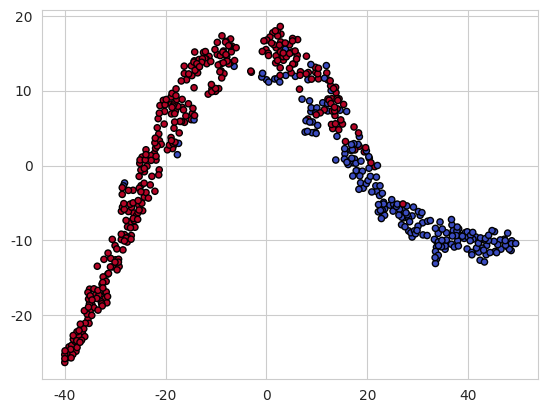

In [ ]:
### 산점도(Scatter Plot) 시각화 :
## 데이터가 2차원 평면상에 어떻게 분포되어 있는지 점을 찍어 확인합니다.

# 축소된 좌표의 첫 번째 열(x축)과 두 번째 열(y축)을 사용하여 산점도를 그립니다.
# c=y: 타겟 값에 따라 색상을 다르게 지정합니다.
# cmap=plt.cm.coolwarm: 색상 지도를 설정하고, s=20은 점 크기, edgecolors='k'는 점의 테두리를 검정색으로 설정합니다.
plt.scatter(X_comp[:, 0], X_comp[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### KNN 모델 학습 및 예측 :
### 차원 축소된 데이터를 바탕으로 분류 모델을 학습시킵니다.

# KNN 분류기 객체를 생성합니다.
model = KNeighborsClassifier()

# 2차원으로 축소된 데이터(X_comp)와 정답(y)을 사용하여 모델을 학습시킵니다.
model.fit(X_comp, y)

# 학습된 모델을 사용하여 다시 X_comp 데이터에 대한 예측값(predict)을 생성합니다.
predict = model.predict(X_comp)

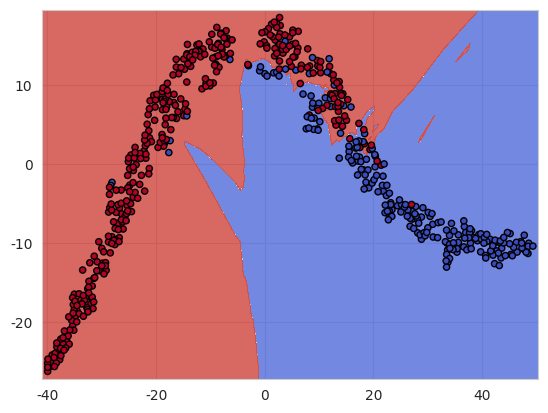

In [ ]:
### 결정 경계(Decision Boundary) 시각화 :
### 모델이 데이터를 어떻게 분류하고 있는지 배경 색상(경계)과 함께 시각화합니다.

# 2차원 평면을 촘촘한 그물망(Grid) 형태로 나누어 좌표값(xx, yy)을 생성합니다.
# 이는 배경색을 칠하기 위한 준비 단계입니다.
xx, yy = make_meshgrid(X_comp[:, 0], X_comp[:, 1])

# 학습된 모델이 그물망의 각 지점을 어떻게 분류하는지 계산하여 색칠(Contour)합니다.
# 이를 통해 모델의 '결정 경계'가 어떻게 형성되었는지 시각적으로 보여줍니다.
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

# 결정 경계 위에 실제 데이터 포인트들을 다시 산점도로 그려서 모델이 잘 맞췄는지 확인합니다.
plt.scatter(X_comp[:, 0], X_comp[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 유방암 데이터_02

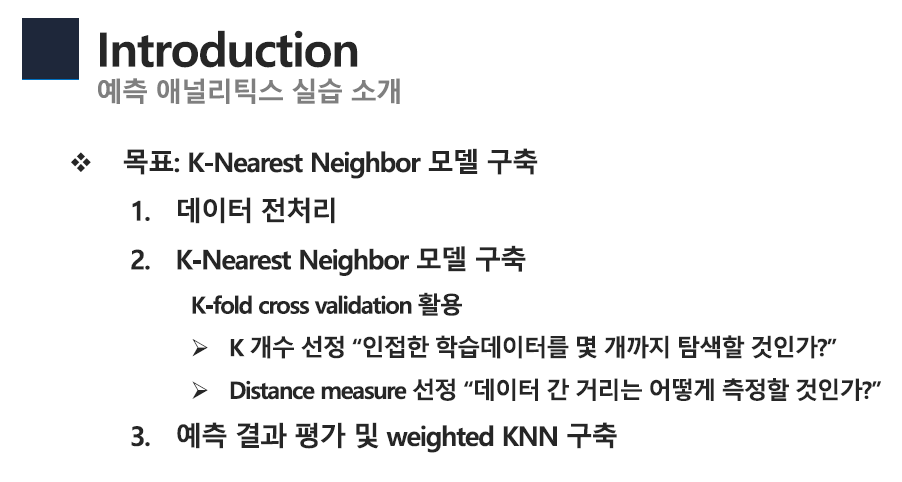

## 1. 모듈 불러오기

In [ ]:
### 라이브러리 임포트 및 설정 :
### 머신러닝 작업에 필요한 도구들을 불러오고 환경을 설정하는 단계


from IPython.display import display, HTML # 주피터 노트북에서 HTML 출력을 예쁘게 하기 위한 도구
import warnings
warnings.filterwarnings(action='ignore') # 실행 중 발생하는 경고 메시지를 무시하여 결과를 깔끔하게 유지

# 실습용 데이터 패키지
from sklearn.datasets import load_breast_cancer # 사이킷런에서 제공하는 위스콘신 유방암 데이터셋 로드 함수

# 데이터 전처리 및 수치 계산
import numpy as np # 수치 연산 및 행렬 처리를 위한 라이브러리
import pandas as pd # 데이터프레임(표 형식) 관리를 위한 핵심 라이브러리
from sklearn.preprocessing import StandardScaler # 데이터를 평균 0, 표준편차 1로 만드는 정규화(Scaling) 도구

# 기계학습 모델 및 평가
from sklearn.model_selection import cross_val_score # 교차 검증을 통해 모델의 성능을 측정하는 함수
from sklearn.model_selection import train_test_split # 데이터를 학습용(Train)과 검증용(Test)으로 나누는 함수
from sklearn.neighbors import KNeighborsClassifier # K-최근접 이웃 분류 알고리즘
from sklearn.neighbors import NearestNeighbors # 이웃 데이터를 찾기 위한 비지도 학습용 알고리즘
from sklearn.metrics import accuracy_score, recall_score, precision_score # 모델 평가 지표 (정확도, 재현율, 정밀도)
from tqdm import tqdm # 반복문 진행 상황을 프로그래스 바(Bar) 형태로 보여주는 라이브러리

# 고급 통계 및 검증용
from sklearn.model_selection import KFold # 데이터를 K개로 쪼개어 검증하는 K-폴드 교차 검증 도구
from scipy.stats import spearmanr # 변수 간의 비선형적 관계를 측정하는 스피어만 상관계수 계산

# 시각화 (그래프 그리기)
import seaborn as sns # 데이터 시각화를 위한 고수준 인터페이스 (matplotlib 기반)
import matplotlib.pyplot as plt # 가장 기본적인 파이썬 그래프 라이브러리
import matplotlib.patches as mpatches # 그래프에 도형(범례 등)을 추가하기 위한 도구
import matplotlib
from matplotlib.colors import ListedColormap # 그래프 색상 테마 설정을 위한 클래스
matplotlib.rcParams['axes.unicode_minus'] = False # 그래프에서 마이너스(-) 기호가 깨지는 현상 방지

# 한글 폰트 설정 (Windows 기준 'Malgun Gothic')
#plt.rc('font', family='Malgun Gothic')

## 2. 데이터 불러오기: Breast Cancer

#### 데이터 구조
- 데이터: 위스콘신 대학교에서 제공한 유방암 진단결과
- 관측치 개수: 569개
- 변수 개수: 32개 (ID, 진단결과, 30개의 실측변수 값)

#### 설명 변수(원인: 예측값을 설명할 수 있는 변수)      
- id: 환자 식별 번호
- radius: 반경 (중심에서 외벽까지 거리들의 평균값)
- texture: 질감(Gray-Scale값들의 표준편차)
- perimeter: 둘레
- area: 면적
- smoothness: 매끄러움(반경길이의 국소적 변화)
- compactness: 조그만 정도(둘레^2/면적-1)
- concavity: 오목함(윤곽의 오목한 부분의 정도)
- points: 오목한 점의 수
- symmetry: 대칭
- dimension: 프랙탈 차원(해안선 근사-1)
- mean: 3~12번 까지는 평균값을 의미
- se: 13~22번까지는 표준오차를 의미
- worst: 23~32는 각 세포별 구분들에서 제일 큰 3개의 값을 평균낸 값

#### 반응 변수(결과: 예측하고자 하는 값)
- diagnosis: 양성여부(Maligant=1 악성(유방암), Benign=0 양성(단순낭종))

In [ ]:
### 데이터 로드 및 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

# 데이터셋 로드 및 변수에 할당
breast_cancer = load_breast_cancer()

# 데이터셋의 상세 설명 출력 (특징 변수 이름, 클래스 개수, 출처 등 포함)
print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

# 데이터의 구조(행, 열 크기) 확인 - 결과: (전체 샘플 수, 변수 개수)
breast_cancer.data.shape

(569, 30)

## 3. 탐색적 데이터 분석 및 데이터 전처리

$\mathbf{X}$: 독립변수, 예측변수, 입력변수 <br>
$\mathbf{y}$: 종속변수, 반응변수, 출력변수

In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

# 딕셔너리 형태의 데이터를 분석하기 좋게 판다스 데이터프레임으로 변환
# X: 독립 변수 (의료 측정 수치들), columns에 특징 이름 부여
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
# y: 종속 변수 (진단 결과: 악성=0, 양성=1), 열 이름을 'diagnosis'로 지정
y = pd.DataFrame(breast_cancer.target, columns=['diagnosis'])

In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

X.head() # 데이터프레임의 상위 5개 행을 확인 (데이터가 잘 들어갔는지 체크)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

y.tail() # 데이터프레임의 하위 5개 행을 확인

,diagnosis
564,0
565,0
566,0
567,0
568,1


### 결측치, 데이터 타입 확인

In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

X.info() # 각 컬럼의 데이터 타입(int, float)과 결측치(Null) 존재 여부 요약

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

결측치가 없고 모든데이터가 float(실수값)데이터 타입이다.

In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

X.describe() # 각 컬럼별 기초 통계량 (평균, 표준편차, 최솟값, 4분위수, 최댓값) 출력

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
### 데이터 탐색 :
### 데이터를 불러와서 어떤 정보들이 들어있는지 확인하는 과정

# 종속 변수의 분포 확인 (악성 vs 양성 비율 확인 - 데이터 불균형 여부 파악 목적)
y['diagnosis'].value_counts()  # 양성과 악성이 각각 몇개씩인지 확인가능.

,count
diagnosis,
1,357
0,212


### Train/Test 데이터 분리
- Training 데이터 70% / Testing 데이터 30% 나누기

In [ ]:
### 데이터 분할 및 정규화 :
### 모델 학습을 위해 데이터를 쪼개고, 단위(Scale)를 맞추는 전처리 단계


# 1. Train set(학습용)과 Test set(평가용) 나누기
# stratify=y: 타겟(y)의 (원래의)비율을 유지하며 분할 (한쪽으로 정답이 쏠리는 것 방지)
#-(ex:train set이나 test set에 1이나 0이 몰려있을경우를대비)
# test_size=0.3: 전체의 30%를 테스트용으로 사용
# random_state=2021: 코드를 다시 실행해도 동일하게 분할되도록 결과 고정
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=2021)
# y의 변수명이 바뀔 경우 stratify=에도 똑같은 변수명으로 바꿔줘야함.

# 2. 데이터 정규화(Standardization) : 데이터 컬럼 단위 정규화 하기
# 모델이 숫자의 '크기'에만 현혹되지 않도록 모든 변수의 범위를 평균 0, 표준편차 1로 맞춤 (특히 KNN에서 필수)
normalizer = StandardScaler()
# fit_transform: Train 데이터의 평균과 표준편차를 학습(fit)하고 동시에 변환(transform)
X_train = normalizer.fit_transform(X_train)
# transform: Train 데이터에서 학습된 기준을 그대로 사용하여 Test 데이터만 변환 (테스트 데이터 정보 유출 방지)
X_test = normalizer.transform(X_test)

# 최종 처리된 데이터의 크기 확인
print(f'Train set dimension is {X_train.shape}') # 학습 데이터 개수와 변수 개수
print(f'Test set dimension is {X_test.shape}')   # 테스트 데이터 개수와 변수 개수

Train set dimension is (398, 30)
Test set dimension is (171, 30)


## 4. 모델링
- K 개수 결정
- Distance measure 결정

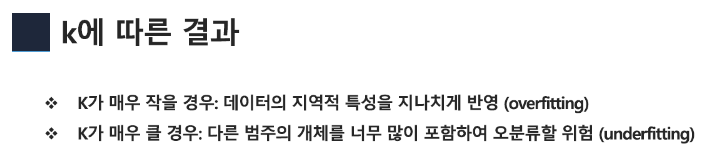

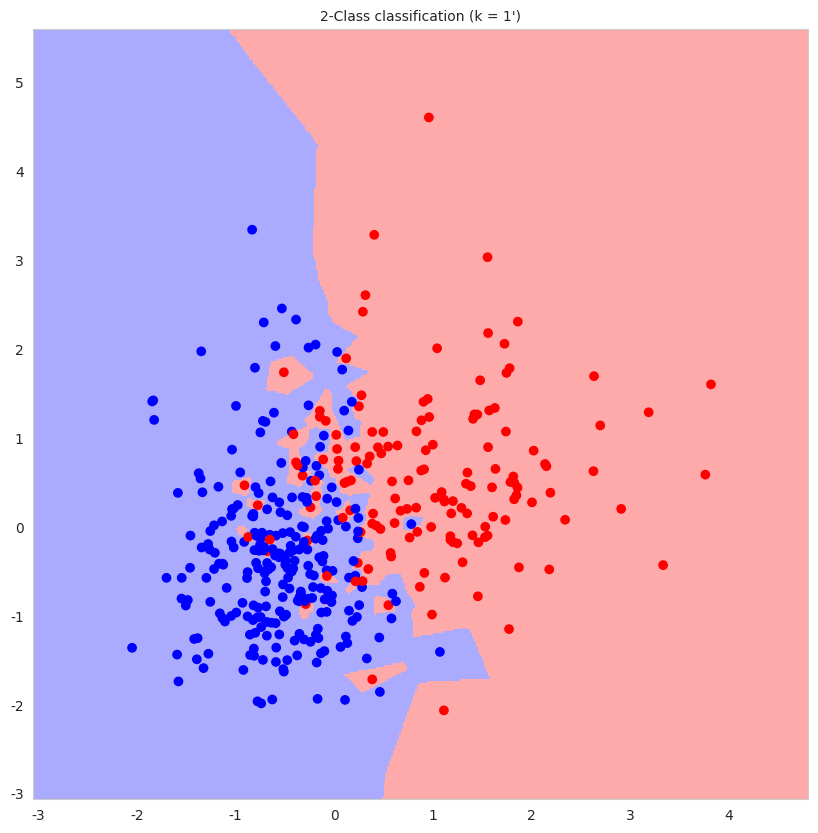

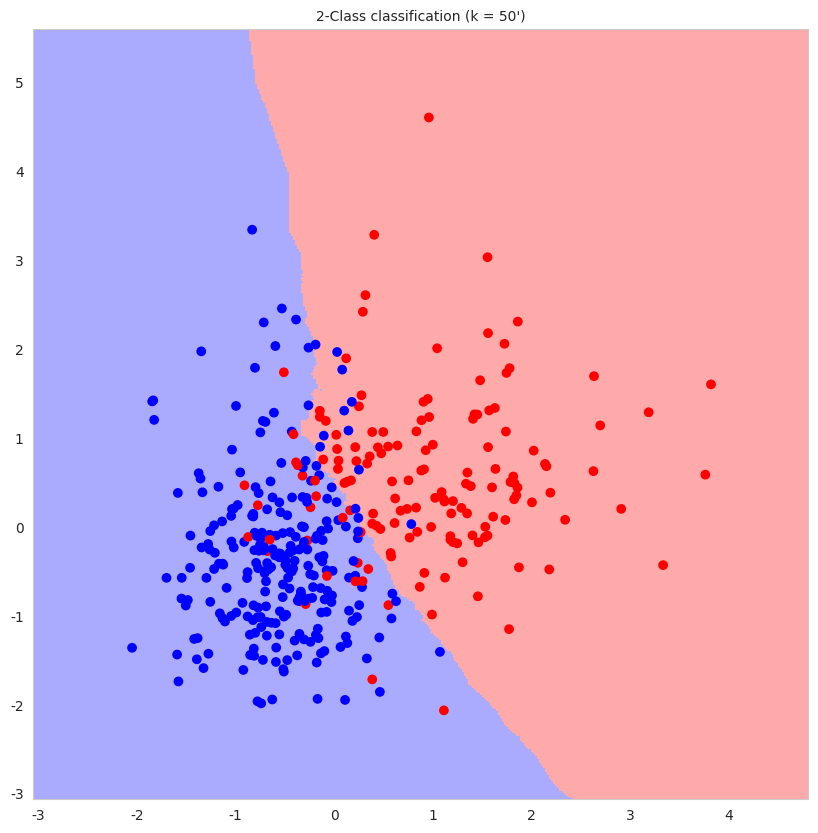

In [ ]:
### K-최근접 이웃(KNN) 알고리즘에서 이웃의 수(k)에 따라 결정 경계(Decision Boundary)가 어떻게 변하는지
### 특히 k=1일 때(복잡한 경계)와 k=50일 때(단순한 경계)를 비교하여
### 과적합(Overfitting)과 과소적합(Underfitting)의 개념을 시각적으로 보여줍니다.


# 시각화를 위해 처음 2개의 특징(Feature)만 선택 (2차원 평면에 그리기 위함)
X_vis = X_train[:, :2] # we only take the first two features. We could
                        # avoid this ugly slicing by using a two-dim dataset
# 종속 변수(y)를 1차원 배열 형태로 평탄화 (학습 모델 입력 형식에 맞춤)
y_vis = y_train.values.ravel()

# 메쉬그리드(배경 격자)를 만들 때의 간격 설정 (작을수록 경계가 부드러워짐)
h = .02    # step size in the mesh

# 시각화를 위한 색상 지도(Color Map) 생성
# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']) # 결정 영역 배경색
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])  # 실제 데이터 포인트 색상

# k가 1일 때와 50일 때의 차이를 보기 위한 반복문
for k in [1, 50]:
    # we create an instance of Neighbours Classifier and fit the data.
    # KNN 분류기 인스턴스 생성 및 2개의 특징 데이터로 학습
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_vis, y_vis)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    # 결정 경계를 그리기 위해 그래프의 최소/최대 범위를 설정 (데이터 주변에 여백 1 추가)
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

    # 설정된 범위 내에서 h 간격으로 모든 좌표 점(Grid) 생성
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 생성된 모든 격자 점들에 대해 모델이 어떤 클래스로 예측하는지 계산
    # np.c_는 두 배열을 열 방향으로 붙여 (x, y) 좌표 쌍을 만듦
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # 예측 결과를 다시 격자 구조(xx의 모양)로 재배열
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)

    # 그래프 크기 설정 및 배경색(결정 영역) 칠하기
    plt.figure(figsize=(10,10))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # 실제 학습 데이터 포인트들을 산점도로 표시
    # Plot also the training points
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold)

    # 축 범위 설정 및 제목 표시
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"2-Class classification (k = {k}')", fontsize=10)

# 생성된 모든 그래프 출력
plt.show()

k값에따라 경계(바운더리)가 굉장히 로컬한지, 굉장이 글로벌한지 확인가능.

과적합(Overfitting)과 과소적합(Underfitting)의 개념을 시각적으로 확인가능.

### 4.1 Hyperparameter k 결정

In [ ]:
### 하이퍼파라미터 :
### k 탐색 및 교차 검증 수행이 단계에서는 홀수 위주의 k 값들을 변경해가며 모델의 정확도를 측정합니다.


# 1부터 99까지의 숫자 중 홀수만 추출하여 k 후보 리스트 생성 (짝수는 타이 발생 가능성 때문에 주로 홀수 사용)
k_list = [i for i in range(1,100) if i%2 !=0]

# 각 k값에 따른 교차 검증 평균 점수를 저장할 빈 리스트
cv_scores = []

# tqdm을 사용하여 반복문 진행 상황(몇%)을 시각적으로 표시하면서 k값 순회
# k값을 순차적으로 넣으면서 루프를 돈다.
for k in tqdm(k_list):
    # KNN 분류기 생성: n_neighbors는 고려할 이웃 수, p=2는 유클리드 거리 방식 사용
    # p=1: 맨해튼 거리, p=2: 유클리드 거리, p=n: 민코프스키 거리
    classifier = KNeighborsClassifier(n_neighbors = k, p=2)  # p=1: manhattan_distance , p=2: euclidean_distance
                                                             # p=l_p: minkowski_distance

    # cross_val_score: 데이터를 10개(cv=10)로 나눠 검증하는 교차 검증 수행
    # X_train, y_train 데이터를 사용하며 평가지표는 'accuracy'(정확도)로 설정
    scores = cross_val_score(classifier, X_train, y_train, cv=10, scoring = 'accuracy')

    # 10번의 교차 검증 결과값들의 평균을 구해 cv_scores 리스트에 추가
    cv_scores.append(scores.mean())

100%|██████████| 50/50 [00:04<00:00, 11.07it/s]


In [ ]:
### 최적의 k값 도출
### 계산된 점수 중 가장 높은 점수를 가진 k를 찾습니다.

# cv_scores 리스트에서 최대값(가장 높은 정확도)과 일치하는 인덱스의 k값을 k_list에서 추출
# 동일한 최대 점수가 여러 개일 경우를 대비하여 리스트 컴프리헨션 사용
# 해당 최대점수의 인덱스값을 best_k에 할당
best_k = [k_list[i] for i in range(len(cv_scores)) if cv_scores[i] == np.max(cv_scores)]

# 찾은 최적의 k값 출력
print("Best k value : ", best_k)

Best k value :  [5]


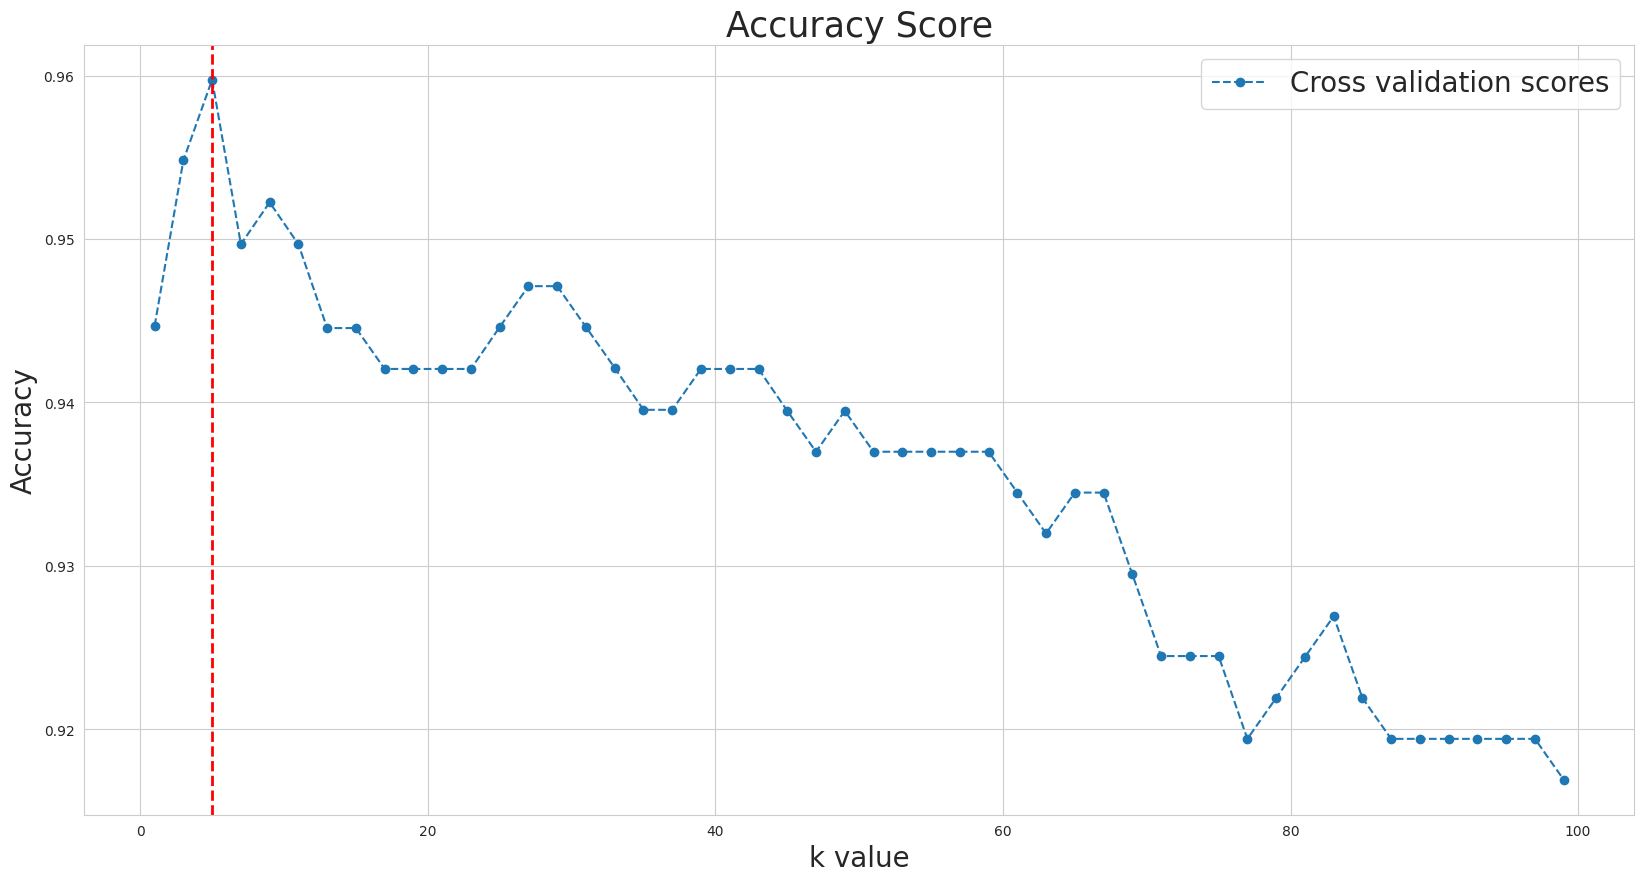

In [ ]:
### 결과 시각화 :
### k의 변화에 따른 정확도(점수) 변화를 그래프로 그려 직관적으로 파악합니다.


# 그래프 크기 설정 (가로 20, 세로 10)
plt.figure(figsize=(20,10))

# x축은 k값, y축은 정확도로 꺾은선 그래프 그리기 (마커는 원형, 선 스타일은 점선)
plt.plot(k_list, cv_scores, marker='o', linestyle='dashed')

# 범례 표시 및 폰트 크기 설정
plt.legend(["Cross validation scores"], fontsize=20)

# x축 라벨(k값) 및 y축 라벨(정확도) 설정
plt.xlabel("k value", fontsize=20 )
plt.ylabel("Accuracy", fontsize=20)

# 그래프 제목 설정
plt.title("Accuracy Score", fontsize=25)

# 최적의 k값 위치에 빨간색(color='r') 수직 점선을 그어 강조 (여러 개일 경우 첫 번째 값 기준)
plt.axvline(best_k[0], color='r', linestyle='--', linewidth=2)

# 그래프 화면 출력
plt.show()

### 4.2 Distance type 결정

#### 4.2.1. Euclidean Distance

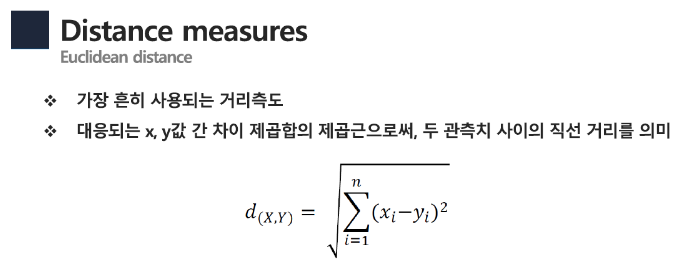

In [ ]:
### 거리 측정 방식에 따른 비교 :
### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

### 유클리드 거리 (Euclidean Distance)

k_list = [i for i in range(1,100) if i%2 !=0]

euc = [] # 유클리드 방식의 결과를 담을 리스트
for k in tqdm(k_list):
    # p=2 (유클리드 거리: 두 점 사이의 최단 직선 거리) 적용
    classifier = KNeighborsClassifier(n_neighbors = k, p=2)
    scores = cross_val_score(classifier, X_train, y_train, cv=10, scoring = 'accuracy')
    euc.append(scores.mean())

100%|██████████| 50/50 [00:03<00:00, 14.35it/s]


#### 4.2.2. Manhattan Distance

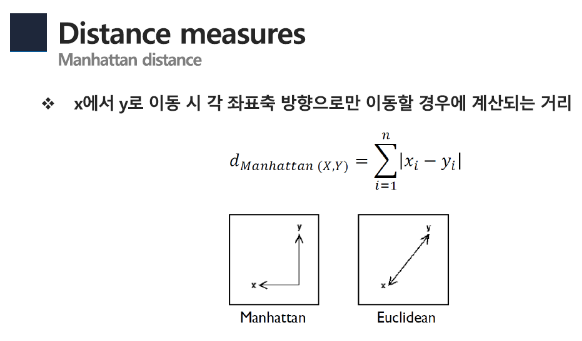

In [ ]:
### 거리 측정 방식에 따른 비교 :
### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

### 맨해튼 거리 (Manhattan Distance)

k_list = [i for i in range(1,100) if i%2 !=0]

man = [] # 맨해튼 방식의 결과를 담을 리스트
for k in tqdm(k_list):
    # p=1 (맨해튼 거리: 격자 형태의 이동 거리 합) 적용
    classifier = KNeighborsClassifier(n_neighbors = k, p=1)
    scores = cross_val_score(classifier, X_train, y_train, cv=10, scoring = 'accuracy')
    man.append(scores.mean())

100%|██████████| 50/50 [00:03<00:00, 15.22it/s]


아래의 코드부터(아래의 3가지 거리 계산에 있어서)는 KNeighborsClassifier에 P값으로 제공하고 있지않다.

#### 4.2.3. Mahalanobis Distance

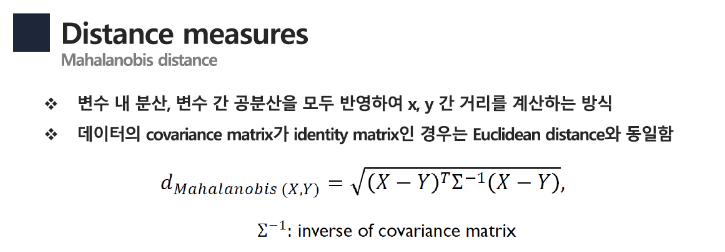

In [ ]:
#### 거리 측정 방식에 따른 비교 :
#### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

#### 마할라노비스 거리(Mahalanobis Distance)

## y_train 데이터를 1차원 배열로 평탄화 (학습 모델에 적합한 형태로 변환)
#y_train = y_train.values.ravel()

## K-Fold 교차 검증 객체 생성: 데이터를 10개의 덩어리(Fold)로 나눔
#kf = KFold(n_splits=10)
#kf.get_n_splits(X_train)

## 이웃의 수(k) 후보 리스트 생성 (1~99 중 홀수)
#k_list = [i for i in range(1,100) if i%2 !=0]

## 마할라노비스 거리 기반의 최종 평균 정확도들을 담을 리스트
#mah = []

## 각 k값에 대해 반복 수행
#for k in tqdm(k_list):

#    # 현재 k값에 대한 각 Fold별 정확도를 저장할 리스트
#    mah_acc = []

#    # 데이터를 학습용(train)과 검증용(valid) 인덱스로 분할하여 반복
#    for train_index, valid_index in kf.split(X_train):
#        # 인덱스를 사용하여 실제 데이터 추출
#        X_train_f = X_train[train_index]
#        y_train_f = y_train[train_index]

#        X_valid_f = X_train[valid_index]
#        y_valid_f = y_train[valid_index]

#        total = len(y_valid_f)  # 검증 데이터의 총 개수
#        correct = 0              # 맞춘 개수 초기화

#        # NearestNeighbors 객체 생성
#        # metric='mahalanobis': 마할라노비스 거리 사용
#        # metric_params: 마할라노비스 계산에 필요한 공분산 행렬(V)을 현재 학습 데이터 기준으로 계산
#        nn = NearestNeighbors(algorithm='brute', metric='mahalanobis',
#                              metric_params={'V':np.cov(X_train_f, rowvar=False)}, n_neighbors=k)

#        # 모델 학습 (학습 데이터의 위치 정보 저장)
#        nn_model = nn.fit(X_train_f, y_train_f)

#        # 검증 데이터셋의 각 샘플(v)에 대해 반복 예측
#        for v in range(len(X_valid_f)):
#            # 현재 샘플과 가장 가까운 k개의 거리와 인덱스 추출
#            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

#            # 다수결 투표를 위한 딕셔너리 (클래스 0과 1의 빈도 측정)
#            class_list = {'0':0, '1':0}
#            for i in range(len(indices[0])):
#                # k개의 이웃 중 해당 인덱스의 실제 정답(y_train_f) 확인
#                if y_train_f[indices[0][i]] == 0:
#                    class_list['0'] += 1
#                else :
#                    class_list['1'] += 1

#            # 가장 많이 나온 클래스(투표 결과)를 선택
#            max_key = np.int(max(class_list, key=class_list.get))

#            # 예측값(max_key)이 실제 정답(y_valid_f[v])과 같으면 맞춘 개수 증가
#            if max_key == y_valid_f[v]:
#                correct += 1

#        # 현재 Fold에서의 정확도(맞춘개수/전체개수) 저장
#        mah_acc.append(correct/total)

#    # 10번의 Fold 결과(정확도)의 평균을 계산하여 최종 리스트에 추가
#    mah.append(np.mean(mah_acc))

In [ ]:
### 거리 측정 방식에 따른 비교 :
### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

### 마할라노비스 거리(Mahalanobis Distance)

# y_train 데이터를 1차원 배열로 평탄화 (학습 모델에 적합한 형태로 변환)
# y_train = y_train.values.ravel() # 이전에 이미 실행되어 y_train이 numpy.ndarray가 되었으므로, 이 줄은 주석 처리합니다.

# K-Fold 교차 검증 객체 생성: 데이터를 10개의 덩어리(Fold)로 나눔
kf = KFold(n_splits=10)
kf.get_n_splits(X_train)

# 이웃의 수(k) 후보 리스트 생성 (1~99 중 홀수)
k_list = [i for i in range(1,100) if i%2 !=0]

# 마할라노비스 거리 기반의 최종 평균 정확도들을 담을 리스트
mah = []

# 각 k값에 대해 반복 수행
for k in tqdm(k_list):

    # 현재 k값에 대한 각 Fold별 정확도를 저장할 리스트
    mah_acc = []

    # 데이터를 학습용(train)과 검증용(valid) 인덱스로 분할하여 반복
    for train_index, valid_index in kf.split(X_train):
        # 인덱스를 사용하여 실제 데이터 추출
        X_train_f = X_train[train_index]
        y_train_f = y_train.iloc[train_index].values.ravel()

        X_valid_f = X_train[valid_index]
        y_valid_f = y_train.iloc[valid_index].values.ravel()

        total = len(y_valid_f)  # 검증 데이터의 총 개수
        correct = 0              # 맞춘 개수 초기화

        # 마할라노비스 거리 계산을 위한 공분산 행렬의 역행렬을 계산
        VI = np.linalg.inv(np.cov(X_train_f, rowvar=False))

        # NearestNeighbors 객체 생성
        # metric='mahalanobis': 마할라노비스 거리 사용
        # metric_params: 마할라노비스 계산에 필요한 공분산 행렬의 역행렬(VI)을 전달
        nn = NearestNeighbors(algorithm='brute', metric='mahalanobis',
                              metric_params={'VI':VI}, n_neighbors=k)

        # 모델 학습 (학습 데이터의 위치 정보 저장)
        nn_model = nn.fit(X_train_f, y_train_f)

        # 검증 데이터셋의 각 샘플(v)에 대해 반복 예측
        for v in range(len(X_valid_f)):
            # 현재 샘플과 가장 가까운 k개의 거리와 인덱스 추출
            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

            # 다수결 투표를 위한 딕셔너리 (클래스 0과 1의 빈도 측정)
            class_list = {'0':0, '1':0}
            for i in range(len(indices[0])):
                # k개의 이웃 중 해당 인덱스의 실제 정답(y_train_f) 확인
                if y_train_f[indices[0][i]] == 0:
                    class_list['0'] += 1
                else :
                    class_list['1'] += 1

            # 가장 많이 나온 클래스(투표 결과)를 선택
            max_key = int(max(class_list, key=class_list.get))

            # 예측값(max_key)이 실제 정답(y_valid_f[v])과 같으면 맞춘 개수 증가
            if max_key == y_valid_f[v]:
                correct += 1

        # 현재 Fold에서의 정확도(맞춘개수/전체개수) 저장
        mah_acc.append(correct/total)

    # 10번의 Fold 결과(정확도)의 평균을 계산하여 최종 리스트에 추가
    mah.append(np.mean(mah_acc))

100%|██████████| 50/50 [00:22<00:00,  2.19it/s]


KNeighborsClassifier 함수말고 NearestNeighbors함수에 metric='mahalanobis'를 써서 마할라노비스 거리(Mahalanobis Distance) 사용가능.

1.   K-Fold Cross Validation (kf.split):
데이터를 10등분하여 9개로 학습하고 1개로 검증하는 과정을 10번 반복합니다. 이는 특정 데이터셋에만 과적합되는 것을 방지하고 모델의 일반화 성능을 정확히 측정하게 해줍니다.

2.   마할라노비스 거리 (metric='mahalanobis'):
단순한 직선 거리가 아니라, 데이터의 분포 형태를 고려합니다. np.cov(X_train_f, rowvar=False)를 통해 데이터의 변수 간 상관관계를 계산하여 거리 측정에 반영하므로, 변수 간의 단위가 다르거나 상관성이 높을 때 매우 유용합니다.

3.   NearestNeighbors vs KNeighborsClassifier:
이 코드는 사이킷런의 완성된 분류기(KNeighborsClassifier)를 쓰는 대신, 저수준 라이브러리인 NearestNeighbors를 호출하여 직접 다수결 투표(Majority Voting) 로직을 구현했습니다. 이는 거리 계산 방식이나 투표 과정을 더 세밀하게 제어하고 싶을 때 사용되는 방식입니다

#### 4.2.4. Correlation Distance - Pearson Correlation

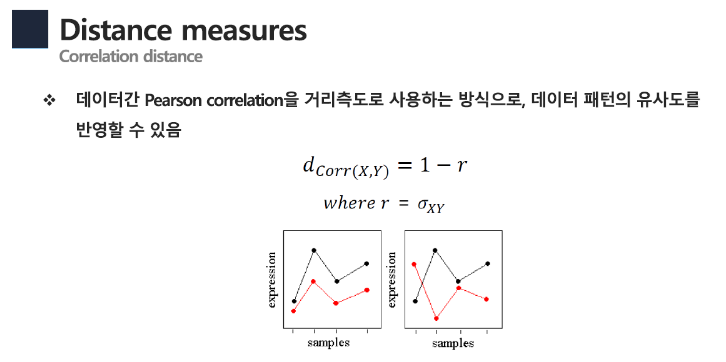

In [ ]:
#### 거리 측정 방식에 따른 비교 :
#### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

#### 상관관계 거리-피어슨 상관계수(Correlation Distance - Pearson Correlation)

## K-Fold 교차 검증 설정: 전체 데이터를 10개의 그룹(Fold)으로 나눔
#kf = KFold(n_splits=10)
#kf.get_n_splits(X_train)

## 테스트할 이웃의 수(k) 후보 리스트 (1~99 사이의 홀수)
#k_list = [i for i in range(1,100) if i%2 !=0]

## 각 k값에 대한 최종 평균 정확도를 저장할 리스트
#pear = []

## 각 k값(이웃 수)에 대해 반복
#for k in tqdm(k_list):

#    # 현재 k값에서 각 Fold별로 계산된 정확도를 담을 임시 리스트
#    pear_acc = []

#    # K-Fold 분할을 순회하며 학습(train)과 검증(valid) 데이터 인덱스 추출
#    for train_index, valid_index in kf.split(X_train):
#        # 인덱스에 해당하는 실제 학습용 데이터 슬라이싱
#        X_train_f = X_train[train_index]
#        y_train_f = y_train[train_index]

#        # 인덱스에 해당하는 실제 검증용 데이터 슬라이싱
#        X_valid_f = X_train[valid_index]
#        y_valid_f = y_train[valid_index]

#        total = len(y_valid_f)  # 이번 Fold에서 검증할 데이터 총 개수
#        correct = 0              # 맞춘 개수 초기화

#        # NearestNeighbors 객체 생성
#        # metric='correlation': 두 데이터 사이의 '상관관계 거리'를 사용 (값이 작을수록 패턴이 비슷함)
#        nn = NearestNeighbors(metric='correlation', n_neighbors=k)

#        # 학습 데이터 적합 (상관관계 계산을 위한 준비)
#        nn_model = nn.fit(X_train_f, y_train_f)

#        # 검증 데이터셋의 각 샘플(v)을 하나씩 분류 시도
#        for v in range(len(X_valid_f)):
#            # 현재 검증 데이터 샘플과 가장 '상관관계가 높은' k개의 이웃 정보(거리, 인덱스) 추출
#            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

#            # 투표 시스템: k개의 이웃이 어느 클래스에 속하는지 카운트
#            class_list = {'0':0, '1':0}
#            for i in range(len(indices[0])):
#                # 이웃의 인덱스를 이용해 실제 정답(Label) 확인 후 득표수 증가
#                if y_train_f[indices[0][i]] == 0:
#                    class_list['0'] += 1
#                else :
#                    class_list['1'] += 1

#            # 가장 많은 표를 얻은 클래스를 최종 예측값으로 선택
#            max_key = np.int(max(class_list, key=class_list.get))

#            # 예측이 실제 정답과 일치하면 맞춘 개수 증가
#            if max_key == y_valid_f[v]:
#                correct += 1

#        # 현재 Fold의 정확도(맞춘 비율) 기록
#        pear_acc.append(correct/total)

#    # 10개의 Fold 결과값의 평균을 내어 현재 k값의 대표 성능으로 저장
#    pear.append(np.mean(pear_acc))

In [ ]:
### 거리 측정 방식에 따른 비교 :
### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

### 상관관계 거리-피어슨 상관계수(Correlation Distance - Pearson Correlation)

# K-Fold 교차 검증 설정: 전체 데이터를 10개의 그룹(Fold)으로 나눔
kf = KFold(n_splits=10)
kf.get_n_splits(X_train)

# 테스트할 이웃의 수(k) 후보 리스트 (1~99 사이의 홀수)
k_list = [i for i in range(1,100) if i%2 !=0]

# 각 k값에 대한 최종 평균 정확도를 저장할 리스트
pear = []

# 각 k값(이웃 수)에 대해 반복
for k in tqdm(k_list):

    # 현재 k값에서 각 Fold별로 계산된 정확도를 담을 임시 리스트
    pear_acc = []

    # K-Fold 분할을 순회하며 학습(train)과 검증(valid) 데이터 인덱스 추출
    for train_index, valid_index in kf.split(X_train):
        # 인덱스에 해당하는 실제 학습용 데이터 슬라이싱
        X_train_f = X_train[train_index]
        # y_train 데이터를 1차원 배열로 평탄화 (학습 모델에 적합한 형태로 변환)
        y_train_f = y_train.iloc[train_index].values.ravel()

        # 인덱스에 해당하는 실제 검증용 데이터 슬라이싱
        X_valid_f = X_train[valid_index]
        # y_valid 데이터를 1차원 배열로 평탄화
        y_valid_f = y_train.iloc[valid_index].values.ravel()

        total = len(y_valid_f)  # 이번 Fold에서 검증할 데이터 총 개수
        correct = 0              # 맞춘 개수 초기화

        # NearestNeighbors 객체 생성
        # metric='correlation': 두 데이터 사이의 '상관관계 거리'를 사용 (값이 작을수록 패턴이 비슷함)
        nn = NearestNeighbors(metric='correlation', n_neighbors=k)

        # 학습 데이터 적합 (상관관계 계산을 위한 준비)
        nn_model = nn.fit(X_train_f, y_train_f)

        # 검증 데이터셋의 각 샘플(v)을 하나씩 분류 시도
        for v in range(len(X_valid_f)):
            # 현재 검증 데이터 샘플과 가장 '상관관계가 높은' k개의 이웃 정보(거리, 인덱스) 추출
            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

            # 투표 시스템: k개의 이웃이 어느 클래스에 속하는지 카운트
            class_list = {'0':0, '1':0}
            for i in range(len(indices[0])):
                # 이웃의 인덱스를 이용해 실제 정답(Label) 확인 후 득표수 증가
                if y_train_f[indices[0][i]] == 0:
                    class_list['0'] += 1
                else :
                    class_list['1'] += 1

            # 가장 많은 표를 얻은 클래스를 최종 예측값으로 선택
            max_key = int(max(class_list, key=class_list.get))

            # 예측이 실제 정답과 일치하면 맞춘 개수 증가
            if max_key == y_valid_f[v]:
                correct += 1

        # 현재 Fold의 정확도(맞춘 비율) 기록
        pear_acc.append(correct/total)

    # 10개의 Fold 결과값의 평균을 내어 현재 k값의 대표 성능으로 저장
    pear.append(np.mean(pear_acc))

100%|██████████| 50/50 [00:20<00:00,  2.41it/s]


1.   상관관계 거리 (Correlation Distance)
이 코드에서 사용한 metric='correlation'은 데이터의 **'절대적인 수치'보다 '변화의 패턴'**이 얼마나 유사한지를 측정합니다.
  *   유클리드 거리: 두 점 사이의 물리적 직선 거리를 잽니다.
  *   상관관계 거리: 두 데이터의 증감 추세(패턴)가 일치하는지를 봅니다. 예를 들어, 데이터의 스케일(단위)이 다르더라도 변화의 흐름이 비슷하면 가깝다고 판단합니다.

2.   직접 구현한 분류 로직
KNeighborsClassifier를 쓰지 않고 NearestNeighbors로 이웃을 찾은 뒤 직접 class_list를 만들어 투표하는 방식을 택했습니다. 이는 KNeighborsClassifier가 기본적으로 지원하지 않는 특수한 거리 척도나 복잡한 투표 가중치를 적용할 때 유용한 방식입니다.

3.   K-Fold의 역할
단순히 한 번만 테스트하는 것이 아니라 데이터를 10번 다르게 쪼개어 테스트하므로, 결과값인 pear 리스트의 점수들은 매우 신뢰도가 높습니다.

#### 4.2.5. Correlation Distance - Spearman Rank Correlation

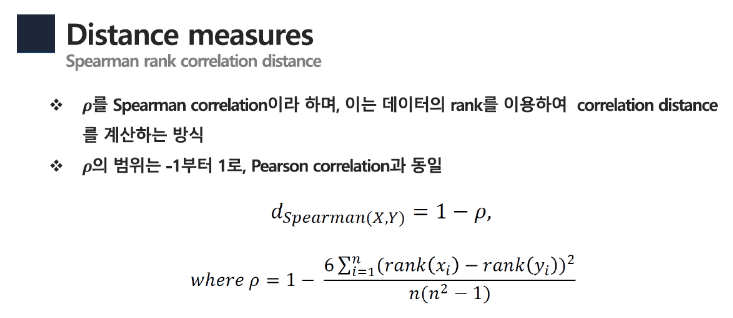

In [ ]:
#### 원본
#### 거리 측정 방식에 따른 비교 :
#### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

#### 스피어먼 상관계수(Spearman's Rank Correlation Coefficient)
#### 이전의 피어슨 상관계수와 비슷하지만, 데이터의 '값' 자체보다 '순위(Rank)'의 일치 정도를 본다는 점에서 차이가 있습니다.

## 스피어먼 상관계수를 거리로 변환하는 사용자 정의 함수
#def spearmancorr(x, y):
#    # spearmanr: 두 데이터의 순위 상관계수(rho)를 계산 (1에 가까울수록 순위가 일치)
#    rho, pval = spearmanr(x, y, axis=0)
#    # 거리는 '멀수록 큰 값'이어야 하므로, 1에서 상관계수를 빼서 거리로 정의 (1-rho)
#    return 1-rho

## K-Fold 교차 검증 설정 (10등분)
#kf = KFold(n_splits=10)
#kf.get_n_splits(X_train)

## 테스트할 이웃의 수(k) 후보 (1~99 홀수)
#k_list = [i for i in range(1,100) if i%2 !=0]

## 스피어먼 거리 기반 최종 정확도를 저장할 리스트
#spear = []

## 각 k값에 대해 반복
#for k in tqdm(k_list):

#    # 현재 k값의 각 Fold별 정확도 기록용
#    spear_acc = []

#    # 10-Fold 교차 검증 시작
#    for train_index, valid_index in kf.split(X_train):
#        # 학습/검증 데이터 분할
#        X_train_f = X_train[train_index]
#        y_train_f = y_train[train_index]

#        X_valid_f = X_train[valid_index]
#        y_valid_f = y_train[valid_index]

#        total = len(y_valid_f)
#        correct = 0

#        # NearestNeighbors 설정
#        # metric=spearmancorr: 위에서 정의한 사용자 함수를 거리 측정에 사용
#        # algorithm='ball_tree': 커스텀 metric을 사용할 때 효율적인 검색을 위한 트리 알고리즘
#        nn = NearestNeighbors(metric = spearmancorr, n_neighbors=k, algorithm='ball_tree')

#        # 모델 학습
#        nn_model = nn.fit(X_train_f, y_train_f)

#        # 검증 데이터 반복 분류
#        for v in range(len(X_valid_f)):
#            # 현재 샘플과 스피어먼 거리가 가장 가까운 k개 탐색
#            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

#            # 다수결 투표 시스템
#            class_list = {'0':0, '1':0}
#            for i in range(len(indices[0])):
#                if y_train_f[indices[0][i]] == 0:
#                    class_list['0'] += 1
#                else :
#                    class_list['1'] += 1

#            # 최종 예측 클래스 결정
#            max_key = np.int(max(class_list, key=class_list.get))

#            # 정답 확인
#            if max_key == y_valid_f[v]:
#                correct += 1

#        # Fold 정확도 추가
#        spear_acc.append(correct/total)

#    # 전체 Fold 평균 정확도 저장
#    spear.append(np.mean(spear_acc))

In [ ]:
### 이방식은 오래걸림(최소30분)


#### 거리 측정 방식에 따른 비교 :
#### 거리 계산 방식(p 파라미터)에 따라 모델 성능이 어떻게 달라지는지 별도로 확인하는 과정

#### 스피어먼 상관계수(Spearman's Rank Correlation Coefficient)
#### 이전의 피어슨 상관계수와 비슷하지만, 데이터의 '값' 자체보다 '순위(Rank)'의 일치 정도를 본다는 점에서 차이가 있습니다.

## 스피어먼 상관계수를 거리로 변환하는 사용자 정의 함수
#def spearmancorr(x, y):
#    # spearmanr: 두 데이터의 순위 상관계수(rho)를 계산 (1에 가까울수록 순위가 일치)
#    rho, pval = spearmanr(x, y, axis=0)
#    # 거리는 '멀수록 큰 값'이어야 하므로, 1에서 상관계수를 빼서 거리로 정의 (1-rho)
#    return 1-rho

## K-Fold 교차 검증 설정 (10등분)
#kf = KFold(n_splits=10)
#kf.get_n_splits(X_train)

## 테스트할 이웃의 수(k) 후보 (1~99 홀수)
#k_list = [i for i in range(1,100) if i%2 !=0]

## 스피어먼 거리 기반 최종 정확도를 저장할 리스트
#spear = []

## 각 k값에 대해 반복
#for k in tqdm(k_list):

#    # 현재 k값의 각 Fold별 정확도 기록용
#    spear_acc = []

#    # 10-Fold 교차 검증 시작
#    for train_index, valid_index in kf.split(X_train):
#        # 학습/검증 데이터 분할
#        X_train_f = X_train[train_index]
#        y_train_f = y_train.iloc[train_index].values.ravel()

#        X_valid_f = X_train[valid_index]
#        y_valid_f = y_train.iloc[valid_index].values.ravel()

#        total = len(y_valid_f)
#        correct = 0

#        # NearestNeighbors 설정
#        # metric=spearmancorr: 위에서 정의한 사용자 함수를 거리 측정에 사용
#        # algorithm='ball_tree': 커스텀 metric을 사용할 때 효율적인 검색을 위한 트리 알고리즘
#        nn = NearestNeighbors(metric = spearmancorr, n_neighbors=k, algorithm='ball_tree')

#        # 모델 학습
#        nn_model = nn.fit(X_train_f, y_train_f)

#        # 검증 데이터 반복 분류
#        for v in range(len(X_valid_f)):
#            # 현재 샘플과 스피어먼 거리가 가장 가까운 k개 탐색
#            distance, indices = nn_model.kneighbors(X_valid_f[v].reshape(1,-1))

#            # 다수결 투표 시스템
#            class_list = {'0':0, '1':0}
#            for i in range(len(indices[0])):
#                if y_train_f[indices[0][i]] == 0:
#                    class_list['0'] += 1
#                else :
#                    class_list['1'] += 1

#            # 최종 예측 클래스 결정
#            max_key = int(max(class_list, key=class_list.get))

#            # 정답 확인
#            if max_key == y_valid_f[v]:
#                correct += 1

#        # Fold 정확도 추가
#        spear_acc.append(correct/total)

#    # 전체 Fold 평균 정확도 저장
#    spear.append(np.mean(spear_acc))

In [ ]:
### 빠른방식

from scipy.stats import rankdata # 데이터의 각 값에 대해 순위를 매기는 함수 (작은 값은 1등, 큰 값은 N등 식)

# 1. 데이터 순위 변환 (Rank Transformation)
# np.apply_along_axis: X_train의 각 행(axis=1, 즉 샘플 하나하나)에 대해 rankdata 함수를 적용
# 결과: 실제 수치(예: 15.5, 12.1)가 아닌 순위(예: 2등, 1등)로 데이터가 재구성됨 (이상치에 강해짐)
X_train_ranked = np.apply_along_axis(rankdata, 1, X_train)

# 2. 타겟 데이터 형식 맞추기
# y_train을 넘파이 배열로 바꾸고 1차원(ravel)으로 펼침 (Scikit-learn 모델 입력의 정석적인 형태)
y_train_values = np.asarray(y_train).ravel()

# 3. K-Fold 교차 검증 설정
# n_splits=10: 전체 학습 데이터를 10등분함
# shuffle=False: 데이터를 섞지 않고 순서대로 나눔 (이미 앞에서 섞인 경우 주로 사용)
kf = KFold(n_splits=10, shuffle=False)

# 4. 테스트할 k값 후보 생성
# 1부터 99까지 2씩 건너뛰며 홀수 리스트 생성 [1, 3, 5, ..., 99]
# 홀수를 쓰는 이유는 투표 결과가 동점이 나오는 것을 방지하기 위함
k_list = [i for i in range(1, 100, 2)]

# 각 k값에 대한 정확도 결과를 저장할 빈 리스트
spear = []

# 5. 최적의 k를 찾기 위한 반복 루프
for k in tqdm(k_list):
    # 스피어만 상관계수 거리 기반 KNN 모델 생성
    # metric="correlation": 순위 데이터에 상관관계 거리를 적용하면 스피어만 거리와 효과가 같아짐
    # algorithm="brute": 모든 데이터와 일일이 대조하는 방식 (데이터가 아주 크지 않을 때 정확함)
    # n_jobs=-1: 컴퓨터의 모든 CPU 코어를 사용하여 연산 속도를 높임
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="correlation",
        algorithm="brute",
        n_jobs=-1
    )

    # 6. 교차 검증 수행
    # cv=kf: 위에서 설정한 10-Fold 방식으로 데이터를 나누어 학습과 검증을 반복
    # scoring="accuracy": 모델의 성능을 '정확도'를 기준으로 평가
    scores = cross_val_score(
        knn,
        X_train_ranked,
        y_train_values,
        cv=kf,
        scoring="accuracy",
        n_jobs=-1
    )

    # 10번의 검증 결과(정확도)의 평균값을 리스트에 추가
    spear.append(scores.mean())

100%|██████████| 50/50 [00:06<00:00,  7.95it/s]


1.   스피어먼 상관계수 거리 ($1-\rho$)

*   원리: 데이터를 크기 순으로 나열하여 '순위'를 매긴 뒤, 그 순위 사이의 상관관계를 측정합니다.
*   장점: 데이터에 아웃라이어(이상치)가 있거나, 수치가 비선형적으로 증가하더라도 순위만 일정하면 높은 점수를 얻습니다. 따라서 데이터의 절대값보다 상대적인 순서가 중요한 경우 매우 강력합니다.

2.   사용자 정의 메트릭과 알고리즘

*   metric = spearmancorr: 사이킷런이 제공하는 기본 거리 외에 연구자가 직접 정의한 수식을 모델에 이식하는 유연한 방법입니다.
*   algorithm = 'ball_tree': 커스텀 거리를 사용할 때 브루트 포스(Brute-force) 방식보다 빠르게 이웃을 찾기 위해 사용되는 구조입니다.

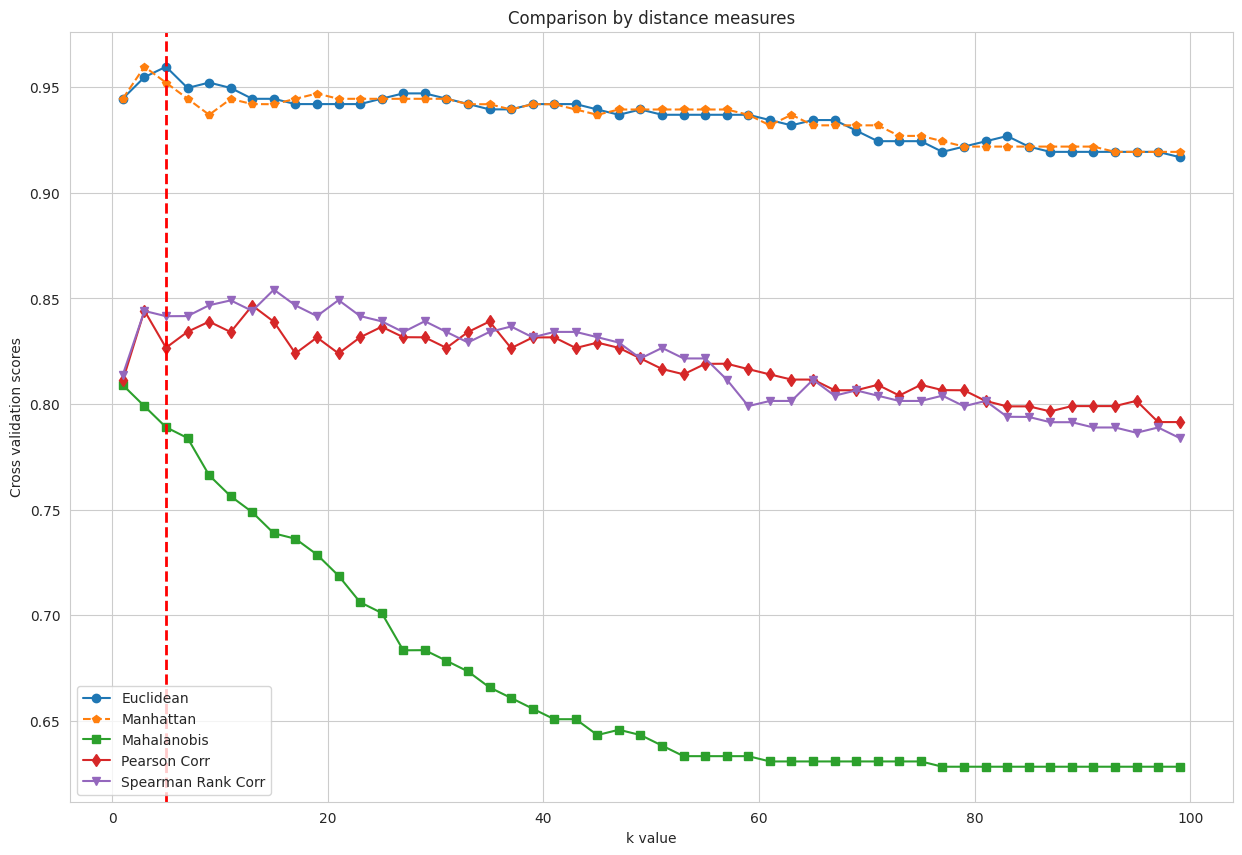

In [ ]:
### 거리 측정 방식별 성능 비교 시각화 :
### 이 부분은 어떤 거리 방식이 가장 높은 정확도를 보이는지, $k$값에 따라 성능이 어떻게 변하는지 한눈에 비교하기 위한 코드입니다.


# 그래프의 전체 크기를 가로 15, 세로 10인치로 설정
plt.figure(figsize=(15,10))

# 주석 처리된 코드: 이전에 사용했거나 제외된 스피어먼 결과 플롯 코드
# plt.plot(k_list, acc_spear, marker='o', linestyle='dashed')

# 1. 유클리드 거리 결과 그래프 (마커: 원형 'o')
plt.plot(k_list, euc, marker='o')

# 2. 맨해튼 거리 결과 그래프 (선 스타일: 점선, 마커: 오각형 'p')
plt.plot(k_list, man, linestyle='dashed', marker='p')

# 3. 마할라노비스 거리 결과 그래프 (마커: 사각형 's')
plt.plot(k_list, mah, marker='s')

# 4. 피어슨 상관관계 거리 결과 그래프 (마커: 다이아몬드 'd')
plt.plot(k_list, pear, marker='d')

# 5. 스피어먼 상관관계 거리 결과 그래프 (마커: 역삼각형 'v')
plt.plot(k_list, spear, marker='v')

# k=5 지점에 빨간색('--') 수직선을 그려 최적의 k 후보를 시각적으로 강조
plt.axvline(5, color='r', linestyle='--', linewidth=2)

# 각 축의 라벨과 그래프 제목 설정
plt.xlabel("k value")
plt.ylabel("Cross validation scores")
plt.title("Comparison by distance measures")

# 각 그래프 선이 무엇을 의미하는지 범례 추가
plt.legend(["Euclidean","Manhattan","Mahalanobis","Pearson Corr","Spearman Rank Corr"])

# 최종 완성된 그래프 출력
plt.show()

결과를 보면 주로 유클리드 거리와 맨해튼 거리의 결과가 점수가 높게 나옴을 알 수 있다.

유클리드 거리에 k가 5일때가 가장 결과가 좋다.

### 4.2 최종 모델 선정 및 성능 확인

이제 테스트 셋에대해 성능을 확인해보자.

In [ ]:
### 최종 모델 구축 및 성능 지표 산출 :
### 그래프 분석 결과, 성능이 가장 좋았던 k=5와 유클리드 거리(p=2)를 사용하여 최종 모델을 만들고 테스트 데이터로 평가합니다.


# 분석 결과 최적으로 판단된 하이퍼파라미터(k=5, p=2)로 KNN 분류기 생성
classifier = KNeighborsClassifier(n_neighbors = 5, p=2)
# 전체 학습 데이터(X_train, y_train)를 사용하여 모델 학습
classifier.fit(X_train, y_train)
# 한 번도 보지 못한 테스트 데이터(X_test)에 대한 예측 수행
y_pred = classifier.predict(X_test)

# 평가지표 1: 정확도(Accuracy) - 전체 중 맞춘 비율
acc = accuracy_score(y_true = y_test, y_pred = y_pred) ## 정확도
# 평가지표 2: 민감도(Recall) - 실제 '참'인 것 중 '참'으로 맞춘 비율 (재현율)
recall = recall_score(y_true = y_test, y_pred = y_pred) ## 민감도
# 평가지표 3: 정밀도(Precision) - '참'이라고 예측한 것 중 실제 '참'인 비율
precision = precision_score(y_true = y_test, y_pred = y_pred) ## 정밀도

# 계산된 지표들을 소수점 둘째 자리까지 포맷팅하여 출력
# sep=' | '를 사용하여 각 항목 사이에 구분선 삽입
print(f"정확도:{acc:0.2f}", f"민감도:{recall:0.2f}", f"정밀도:{precision:0.2f}", sep='  |  ')

정확도:0.98  |  민감도:0.99  |  정밀도:0.97


결과가 좋게나옴을 정량적으로 확인할 수 있다.

*   민감도(Recall): 놓치지 말아야 할 대상을 얼마나 잘 찾았는가입니다. (예: 암 환자 판별)

*   정밀도(Precision): 모델이 '맞다'고 한 것이 얼마나 믿을만한가입니다. (예: 스팸 메일 판별)

### 4.3 Weighted KNN 적용 및 성능확인

100%|██████████| 50/50 [00:03<00:00, 14.85it/s]


Best k value :  [5]


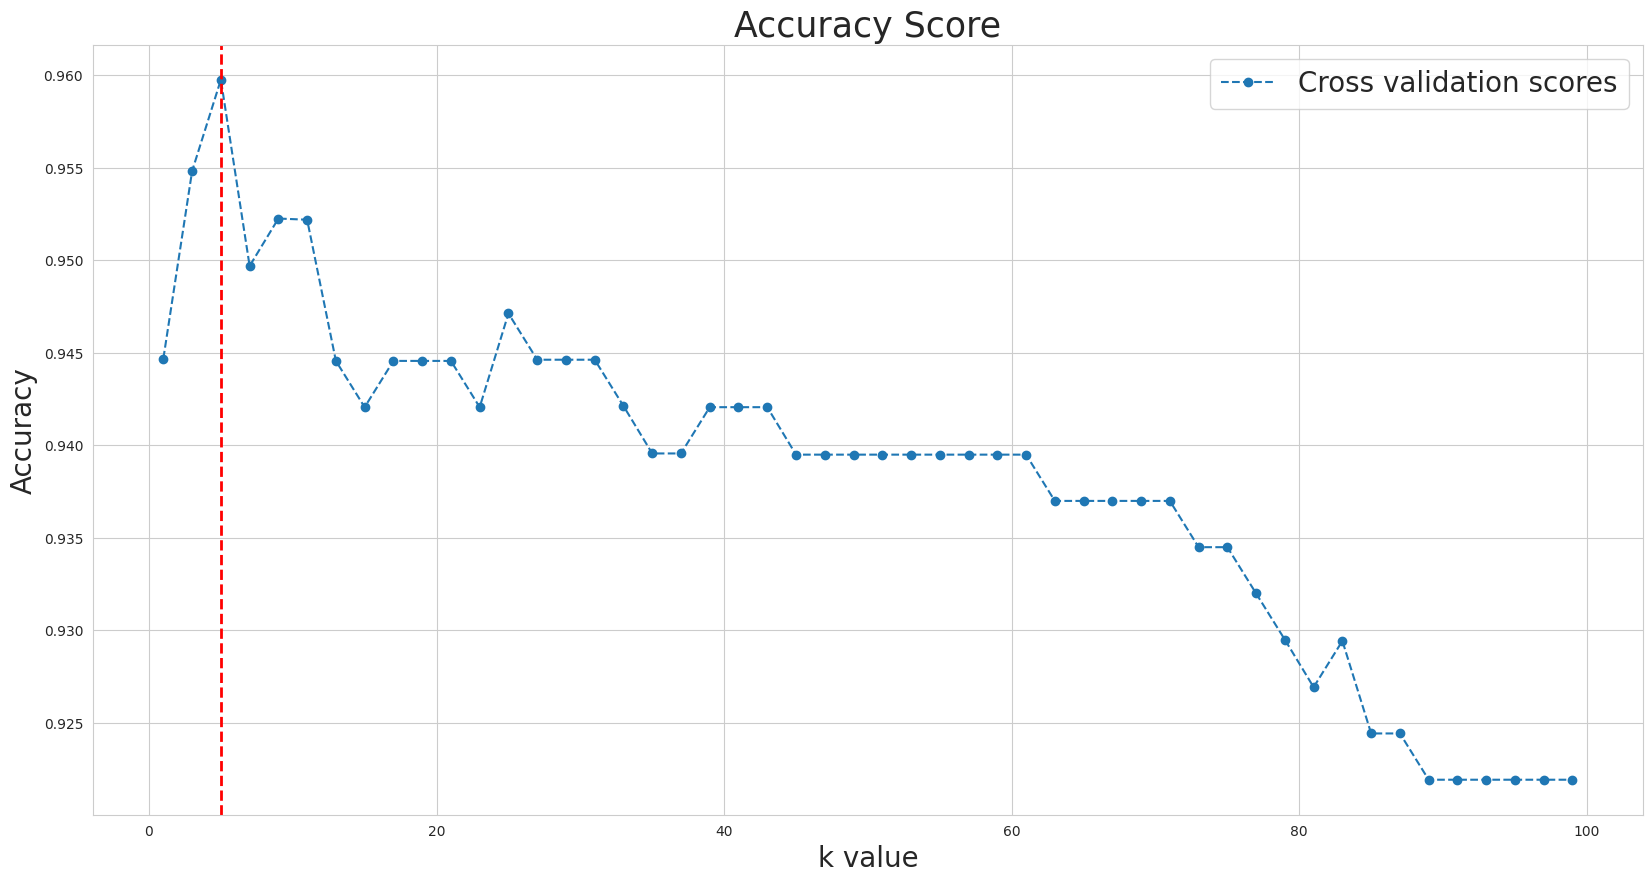

In [ ]:
### KNN 분류: 거리 가중치(Distance Weights) 적용 및 최적 k 탐색 :
### 가까운 이웃에게 더 큰 투표권을 주는 weights='distance' 옵션을 사용하여 성능을 측정합니다.
### Weighted KNN은 weights='distance' 옵션을 사용하여 적용된다.

# 1부터 99까지의 홀수 리스트 생성 (이웃의 수 후보)
k_list = [i for i in range(1,100) if i%2 !=0]

# 각 k값에 대한 유클리드 거리 기반 평균 정확도를 저장할 리스트
euc = []

for k in tqdm(k_list):
    # weights='distance': 가까운 이웃일수록 예측에 더 큰 영향을 미치도록 가중치 부여
    # (기본값인 'uniform'은 모든 이웃의 영향력이 동일함)
    classifier = KNeighborsClassifier(n_neighbors = k, p=2, weights='distance') # weights{‘uniform’, distance’} or callable,
                                                                                # default=’uniform’
    # 10-Fold 교차 검증을 통해 정확도(accuracy) 계산
    scores = cross_val_score(classifier, X_train, y_train, cv=10, scoring = 'accuracy')

    # 10개 결과의 평균값을 리스트에 추가
    euc.append(scores.mean())

# 가장 높은 정확도를 보인 k값들을 추출
best_k = [k_list[i] for i in range(len(euc)) if euc[i] == np.max(euc)]
print("Best k value : ", best_k)

# 시각화 설정
plt.figure(figsize=(20,10))
plt.plot(k_list, euc, marker='o', linestyle='dashed') # k값 변화에 따른 정확도 그래프
plt.legend(["Cross validation scores"], fontsize=20)
plt.xlabel("k value", fontsize=20)
plt.ylabel("Accuracy", fontsize=20)
plt.title("Accuracy Score", fontsize=25)

# 최적의 k값 위치에 빨간 점선 표시
plt.axvline(best_k[0], color='r', linestyle='--', linewidth=2)
plt.show()

In [ ]:
### 가중치 적용 모델의 최종 성능 평가 :
### 최적의 조건(k=5, 가중치 적용)으로 최종 모델의 예측력을 다각도로 검증


# 거리 가중치 방식을 적용한 KNN 분류기 생성 (k=5)
classifier = KNeighborsClassifier(n_neighbors = 5, p=2, weights='distance')

# 학습 데이터로 모델 훈련
classifier.fit(X_train, y_train)

# 테스트 데이터에 대한 클래스 예측
y_pred = classifier.predict(X_test)

# 성능 지표 계산
acc = accuracy_score(y_true = y_test, y_pred = y_pred)       # 정확도: 전체 중 맞춘 비율
recall = recall_score(y_true = y_test, y_pred = y_pred)     # 민감도: 실제 Positive 중 맞춘 비율
precision = precision_score(y_true = y_test, y_pred = y_pred) # 정밀도: Positive로 예측한 것 중 실제 비율

# 결과 출력 (소수점 2자리까지 표시)
print(f"정확도:{acc:0.2f}", f"민감도:{recall:0.2f}", f"정밀도:{precision:0.2f}", sep='  |  ')

정확도:0.98  |  민감도:0.99  |  정밀도:0.97


결과의 성능은 동일하게 나왔다.(weights와 관련없이-왜냐면 데이터셋이 성능이 좋은 데이터라서)

# 와인 데이터

In [ ]:
### 데이터셋 로드

# 사이킷런의 내장 데이터셋인 '와인 데이터'를 불러와서 wine 변수에 저장합니다.
# 이 데이터에는 알코올 도수, 마그네슘 함량 등 와인의 화학적 성분(특성)과 종류(타겟)가 들어 있습니다.
wine = load_wine()

In [ ]:
### 전체 데이터프레임 구성 :
### 원래 배열(Array) 형태인 데이터를 우리가 보기 편한 표(Table) 형태로 변환합니다.

# wine.data(수치들)를 데이터로 사용하고, wine.feature_names(각 컬럼의 이름)를 열 제목으로 지정하여 데이터프레임을 생성합니다.
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# 'Target'이라는 새로운 열을 만들고, 와인의 실제 종류(0, 1, 2번 와인)를 저장합니다.
wine_df['Target'] = wine.target

# 생성된 전체 데이터프레임을 화면에 출력하여 상위/하위 데이터를 확인합니다.
wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [ ]:
### 데이터 분할 (Train/Test Split) :
### 모델의 '실력'을 객관적으로 평가하기 위해 공부할 문제(Train)와 시험 볼 문제(Test)를 나눕니다.

# X에는 입력 데이터(성분들)를, y에는 정답(와인 종류)을 따로 저장합니다.
X, y = wine.data, wine.target

# 전체 데이터를 훈련용과 테스트용으로 분리합니다.
# test_size=0.2는 전체의 20%를 시험 문제(Test)로 떼어놓고, 나머지 80%를 학습(Train)에 쓰겠다는 의미입니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### 훈련용 데이터프레임 생성 :
### 분할된 데이터를 확인하기 쉽게 다시 표 형태로 정리하는 과정

# --- 훈련용 데이터 확인 ---
# 학습에 사용될 80%의 데이터(X_train)를 데이터프레임으로 만듭니다.
wine_train_df = pd.DataFrame(data=X_train, columns=wine.feature_names)
# 학습용 정답지(y_train)를 컬럼으로 추가합니다.
wine_train_df['Target'] = y_train
# 훈련 데이터셋의 구성을 확인합니다.
wine_train_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,13.68,1.83,2.36,17.2,104.0,2.42,2.69,0.42,1.97,3.84,1.23,2.87,990.0,0
1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
2,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564.0,1
3,13.73,4.36,2.26,22.5,88.0,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520.0,2
4,12.37,1.07,2.10,18.5,88.0,3.52,3.75,0.24,1.95,4.50,1.04,2.77,660.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,13.05,5.80,2.13,21.5,86.0,2.62,2.65,0.30,2.01,2.60,0.73,3.10,380.0,1
138,12.47,1.52,2.20,19.0,162.0,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937.0,1
139,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
140,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0,0


In [ ]:
### 훈련용 및 테스트용 데이터프레임 생성 :
### 분할된 데이터를 확인하기 쉽게 다시 표 형태로 정리하는 과정

# --- 테스트용 데이터 확인 ---
# 나중에 모델 평가에 쓰일 20%의 데이터(X_test)를 데이터프레임으로 만듭니다.
wine_test_df = pd.DataFrame(data=X_test, columns=wine.feature_names)
# 평가용 정답지(y_test)를 컬럼으로 추가합니다.
wine_test_df['Target'] = y_test
# 테스트 데이터셋의 구성을 확인합니다.
wine_test_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,13.05,1.77,2.10,17.0,107.0,3.00,3.00,0.28,2.03,5.04,0.88,3.35,885.0,0
1,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
2,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2
3,11.45,2.40,2.42,20.0,96.0,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625.0,1
4,13.07,1.50,2.10,15.5,98.0,2.40,2.64,0.28,1.37,3.70,1.18,2.69,1020.0,0
5,12.25,4.72,2.54,21.0,89.0,1.38,0.47,0.53,0.80,3.85,0.75,1.27,720.0,2
6,13.34,0.94,2.36,17.0,110.0,2.53,1.30,0.55,0.42,3.17,1.02,1.93,750.0,1
7,12.82,3.37,2.30,19.5,88.0,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685.0,2
8,11.76,2.68,2.92,20.0,103.0,1.75,2.03,0.60,1.05,3.80,1.23,2.50,607.0,1
9,12.08,1.13,2.51,24.0,78.0,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630.0,1


In [ ]:
### 데이터 표준화(StandardScaler) 적용 :
### 데이터의 단위(예: 알코올 농도 10~14 vs 마그네슘 70~160)가 다르면 모델이 특정 변수에만 휘둘릴 수 있습니다.
### 이를 평균 0, 표준편차 1로 맞추는 과정입니다.

# StandardScaler 객체를 생성합니다. (평균=0, 분산=1로 변환하는 도구)
scaler = StandardScaler()

# 훈련 데이터(X_train)의 평균과 표준편차를 학습(fit)하고, 그 기준으로 데이터를 변환(transform)합니다.
X_train_scale = scaler.fit_transform(X_train)

# 테스트 데이터(X_test)도 '훈련 데이터에서 얻은 기준'에 맞춰 변환합니다.
# 주의: 테스트 데이터로 fit을 새로 하면 안 됩니다. (데이터 누수 방지)
X_test_scale = scaler.transform(X_test)

In [ ]:
### 스케일링 전(Raw Data) 모델 학습 및 평가 :
### 원본 데이터 그대로 학습했을 때의 성능을 먼저 확인합니다.

# KNN 분류기 모델을 생성합니다.
model = KNeighborsClassifier()

# 스케일링되지 않은 원본 훈련 데이터(X_train)로 모델을 학습시킵니다.
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
### 스케일링 전(Raw Data) 모델 학습 및 평가 :
### 원본 데이터 그대로 학습했을 때의 성능을 먼저 확인합니다.

# 학습 데이터와 평가 데이터의 정확도(Accuracy)를 각각 출력합니다.
# 단위 차이가 크면 점수가 낮게 나올 가능성이 높습니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.7887323943661971
평가 데이터 점수: 0.75


In [ ]:
### 스케일링 후(Scaled Data) 모델 학습 및 평가 :
### 표준화된 데이터를 사용하여 다시 학습하고 성능 변화를 관찰합니다.

# 새로운 KNN 모델 객체를 생성합니다. (이전 모델 초기화)
model = KNeighborsClassifier()

# 표준화된 훈련 데이터(X_train_scale)로 모델을 학습시킵니다.
model.fit(X_train_scale, y_train)

KNeighborsClassifier()

In [ ]:
### 스케일링 후(Scaled Data) 모델 학습 및 평가 :
### 표준화된 데이터를 사용하여 다시 학습하고 성능 변화를 관찰합니다.

# 표준화된 데이터를 사용했을 때의 성능을 출력합니다.
# 일반적으로 KNN에서는 스케일링 후의 점수가 훨씬 높고 안정적입니다.
print("학습 데이터 점수: {}".format(model.score(X_train_scale, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

학습 데이터 점수: 0.971830985915493
평가 데이터 점수: 1.0


In [ ]:
### 간편한 파이프라인 생성 (make_pipeline) :
### 전처리와 모델을 하나로 묶어 데이터 흐름을 자동화합니다.

# 'StandardScaler'와 'KNeighborsClassifier'를 순서대로 연결하는 파이프라인을 생성합니다.
# make_pipeline은 각 단계의 이름을 자동으로 생성(예: standardscaler, kneighborsclassifier)해주는 편리한 함수입니다.
estimator = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

In [ ]:
### 교차 검증 수행 (cross_validate) :
### 데이터를 여러 조각으로 나누어 모델의 일반화 성능을 정밀하게 측정합니다.

# 생성한 estimator(파이프라인)를 사용하여 교차 검증을 수행합니다.
cross_validate(
    estimator=estimator,            # 검증할 모델(여기서는 전처리가 포함된 파이프라인)
    X=X, y=y,                       # 전체 데이터와 정답지
    cv=5,                           # 데이터를 5개로 나누어 5번 테스트(5-Fold CV)
    n_jobs=multiprocessing.cpu_count(), # 모든 CPU 코어를 사용하여 병렬 계산 (속도 최적화)
    verbose=True                    # 검증 진행 상황을 로그로 출력
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:    0.0s finished


{'fit_time': array([0.0032475 , 0.00370193, 0.00432539, 0.00398731, 0.0022943 ]),
 'score_time': array([0.00375104, 0.00378275, 0.00401306, 0.00359988, 0.00260735]),
 'test_score': array([0.94444444, 0.94444444, 0.97222222, 1.        , 0.88571429])}

cross_validate한 결과 좋게 나옴.

In [ ]:
### 명시적 파이프라인 구축 (Pipeline) :
### 그리드 서치에서 각 단계를 제어하기 위해 이름을 직접 지정하여 파이프라인을 만듭니다.

# 각 단계에 'scaler'와 'model'이라는 별칭(Alias)을 부여하며 파이프라인을 정의합니다.
# 이렇게 이름을 정해주어야 나중에 param_grid에서 어떤 단계의 설정값을 바꿀지 지칭할 수 있습니다.
pipe = Pipeline(
    [('scaler', StandardScaler()),
     ('model', KNeighborsClassifier())]
)

In [ ]:
### 하이퍼파라미터 탐색 범위 설정 (param_grid) :
### 모델의 성능을 결정하는 변수들의 후보 리스트를 작성합니다.

# 'model' 단계(KNN)의 하이퍼파라미터 조합을 정의합니다.
param_grid = [{
    'model__n_neighbors': [3, 5, 7],               # 이웃의 수를 3, 5, 7개로 바꿔봄
    'model__weights': ['uniform', 'distance'],      # 거리 가중치 부여 방식 결정
    'model__algorithm': ['ball_tree', 'kd_tree', 'brute'] # 이웃 검색 알고리즘 종류 선택
}]

In [ ]:
### 그리드 서치 설정 및 학습 (GridSearchCV) :
### 모든 조합을 다 시도해보고 "가장 똑똑한 설정"을 찾아내는 과정

# GridSearchCV 객체를 생성하여 최적의 파라미터 조합을 찾을 준비를 합니다.
gs = GridSearchCV(
    estimator=pipe,             # 탐색할 대상 파이프라인
    param_grid=param_grid,      # 시도해볼 파라미터 후보군
    n_jobs=multiprocessing.cpu_count(), # 병렬 처리로 탐색 시간 단축
    verbose=True                # 어떤 조합을 테스트 중인지 실시간 출력
)

In [ ]:
# 실제로 데이터를 넣어 모든 조합(3x2x3 = 18가지 조합 * 5-Fold CV)을 학습하고 평가합니다.
gs.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=2,
             param_grid=[{'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
                          'model__n_neighbors': [3, 5, 7],
                          'model__weights': ['uniform', 'distance']}],
             verbose=True)

In [ ]:
### 최적의 결과 확인 :
### 탐색 결과 가장 성능이 좋았던 모델과 점수를 추출

# 수많은 조합 중 가장 높은 정확도를 기록한 '최적의 파이프라인'을 반환합니다.
# (예: scaler + KNN(n_neighbors=5, weights='distance' 등))
gs.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(algorithm='ball_tree', n_neighbors=7))])

In [ ]:
### 최적의 결과 확인 :
### 탐색 결과 가장 성능이 좋았던 모델과 점수를 추출

# 탐색 과정에서 얻은 가장 높은 평균 교차 검증 점수를 출력합니다.
print('GridSearchCV best score: {}'.format(gs.best_score_))

GridSearchCV best score: 0.9665079365079364


In [ ]:
### t-SNE를 통한 차원 축소 :
### 많은 수의 특성(컬럼)을 가진 데이터를 시각화가 가능한 2차원 좌표로 변환합니다.

# t-SNE(t-distributed Stochastic Neighbor Embedding) 객체를 생성합니다.
# n_components=2는 데이터를 2차원(x, y 좌표)으로 줄이겠다는 설정입니다.
tsne = TSNE(n_components=2)

# 원본 데이터 X의 고차원 구조를 유지하면서 2차원 좌표인 X_comp로 변환합니다.
# fit(데이터 구조 학습)과 transform(좌표 변환)을 동시에 수행합니다.
X_comp = tsne.fit_transform(X)

In [ ]:
### 변환된 데이터의 표(DataFrame)화 :
### 시각화와 데이터 확인을 위해 변환된 좌표를 판다스 데이터프레임으로 정리

# 2차원으로 축소된 좌표 데이터(X_comp)를 데이터프레임으로 만듭니다.
wine_comp_df = pd.DataFrame(data=X_comp)

# 각 샘플의 실제 와인 종류(타겟 값)를 'Target'이라는 이름의 새 열에 저장합니다.
wine_comp_df['Target'] = y

# 결과 데이터프레임을 출력하여 2차원 좌표와 타겟 값이 잘 매칭되었는지 확인합니다.
wine_comp_df

,0,1,Target
0,11.885133,-0.480538,0
1,11.506394,-1.147849,0
2,14.050035,-1.015527,0
3,16.863930,-1.384284,0
4,3.268320,-0.451542,0
...,...,...,...
173,3.289910,-0.019914,2
174,3.707676,-0.103938,2
175,6.272249,-0.490825,2
176,6.423851,-0.620846,2


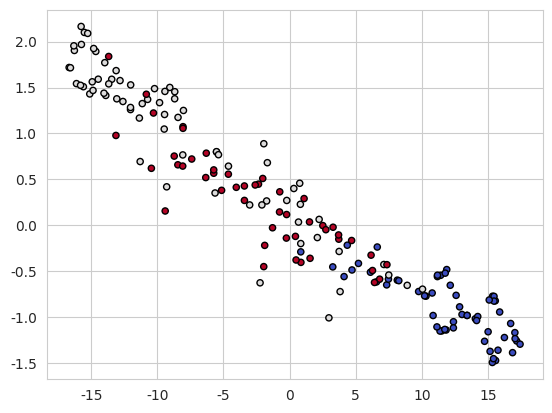

In [ ]:
### 축소된 데이터의 산점도 시각화 :
### 데이터가 2차원 평면상에 어떻게 뭉쳐(Cluster) 있는지 확인

# plt.scatter를 이용해 2차원 좌표의 첫 번째 열(x축)과 두 번째 열(y축)을 점으로 찍습니다.
# c=y: 실제 정답(와인 종류)에 따라 점의 색상을 다르게 표현합니다.
# cmap=plt.cm.coolwarm: 색상 지도를 설정하고, s=20은 점 크기, edgecolors='k'는 테두리를 검정색으로 그립니다.
plt.scatter(X_comp[:, 0], X_comp[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### 압축된 데이터를 이용한 모델 학습 및 예측 :
### 전체 특성이 아닌, t-SNE로 압축된 2개의 좌표만을 사용하여 KNN 모델을 학습

# KNN(K-Neighbors Classifier) 분류기 객체를 생성합니다.
model = KNeighborsClassifier()

# 2차원으로 압축된 데이터(X_comp)와 정답(y)을 사용하여 모델을 학습시킵니다.
model.fit(X_comp, y)

# 학습된 모델을 통해 데이터들이 어떤 종류로 분류되는지 예측 결과(predict)를 생성합니다.
predict = model.predict(X_comp)

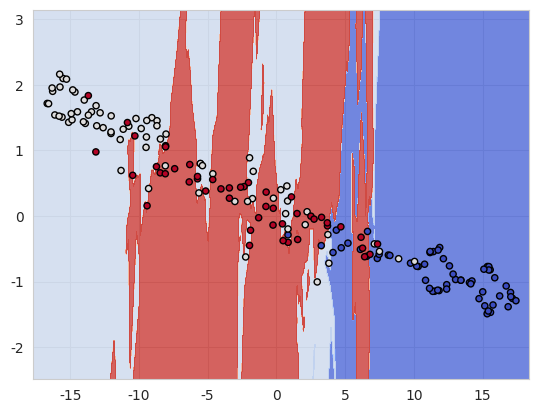

In [ ]:
### 결정 경계(Decision Boundary) 시각화 :
### 모델이 평면을 어떻게 구획하여 분류하고 있는지 배경색과 함께 최종 시각화

# 변환된 좌표의 최소/최대 범위를 바탕으로 평면 전체를 촘촘한 격자(Grid)로 나눕니다.
# xx, yy는 배경에 색을 칠하기 위한 수많은 좌표 포인트들입니다.
xx, yy = make_meshgrid(X_comp[:, 0], X_comp[:, 1])

# 학습된 KNN 모델이 격자의 각 지점을 어떤 와인으로 분류하는지 찾아내어 색을 입힙니다(Contour).
# alpha=0.8은 투명도를 조절하여 데이터 포인트가 잘 보이게 합니다.
plot_contours(model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

# 그 위에 실제 와인 데이터 포인트들을 다시 그려서 모델의 경계와 실제 데이터가 잘 맞는지 확인합니다.
plt.scatter(X_comp[:, 0], X_comp[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# k 최근접 이웃 회귀

*   k 최근접 이웃 분류와 마찬가지로 예측에 이웃 데이터 포인트를 사용
*   이웃 데이터 포인트의 평균이 예측 결과

# 보스턴 주택 가격 데이터

CSV 파일을 성공적으로 불러왔습니다.


100%|██████████| 50/50 [00:03<00:00, 15.58it/s]


Best k value :  [3]


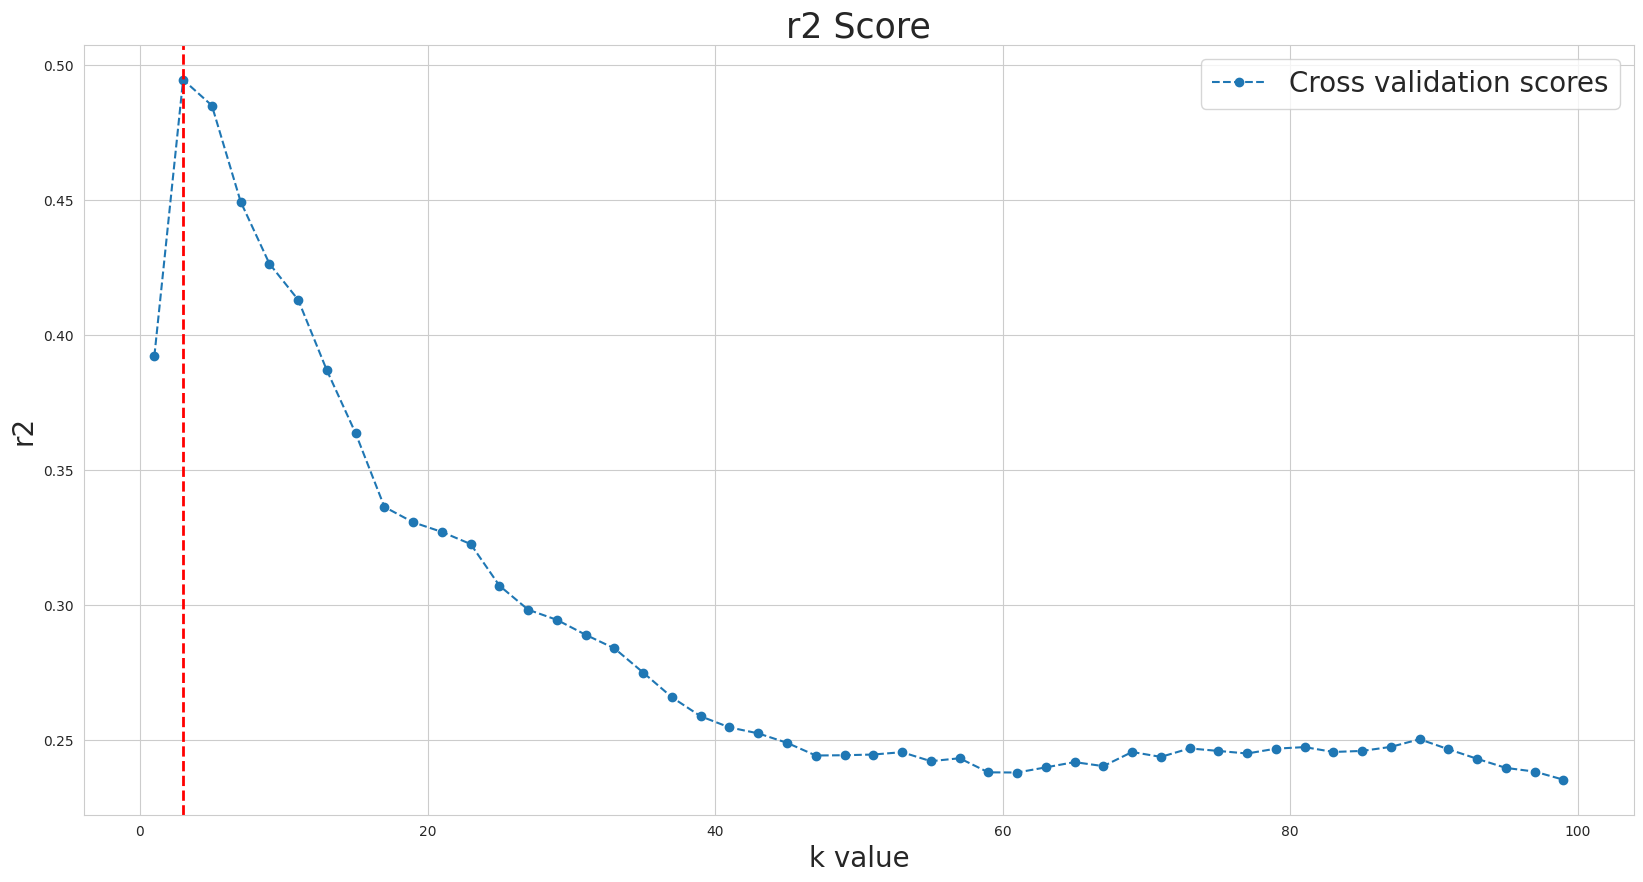

In [ ]:
### 간단 KNN 회귀 - 보스턴
### KNN 회귀(Regressor): 보스턴 주택 가격 예측:
### KNN은 분류뿐만 아니라 연속적인 숫자(가격 등)를 예측하는 회귀 모델로도 사용됩니다.


from sklearn.neighbors import KNeighborsRegressor # 회귀이므로 KNeighborsRegressor를 사용한다.
#from sklearn.datasets import load_boston

## 보스턴 주택 가격 데이터셋 로드
#boston = load_boston()

### 데이터 로드

# 사이킷런 1.2 버전부터 load_boston()이 삭제되었으므로 CSV 파일을 직접 로드합니다.
try:
    boston_df = pd.read_csv("boston.csv") # "boston.csv" 파일을 읽어와 데이터프레임 형태로 저장합니다.
    print("CSV 파일을 성공적으로 불러왔습니다.")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# 데이터 프레임 형태로 변환
# 독립 변수(특성)들을 데이터 프레임으로 변환 (범죄율, 방의 개수 등)
#X = pd.DataFrame(boston.data, columns=boston.feature_names)
# 종속 변수(타겟)인 주택 가격(MEDV)을 데이터 프레임으로 변환
#y = pd.DataFrame(boston.target, columns=['MEDV'])

# 전체 데이터에서 타겟 변수인 'MEDV'(주택 가격)만 제외하여 특성 데이터 X를 만듭니다.
X = boston_df.drop('MEDV', axis=1) # Exclude the target column 'MEDV' to get features
# 'MEDV' 열만 선택하여 예측 목표인 타겟 데이터 y로 설정합니다.
y = boston_df['MEDV'] # Select 'MEDV' as the target column

# 전체 데이터를 학습용 70%, 테스트용 30%로 분할 (고정된 난수 시드 사용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2021)

# 테스트할 이웃 수(k) 후보 리스트
k_list = [i for i in range(1,100) if i%2 !=0]
cv_scores = []

for k in tqdm(k_list):
    # KNeighborsRegressor: 주변 k개의 주택 가격 평균으로 현재 가격을 예측
    # p=2: 유클리드 거리 방식 사용
    regressor = KNeighborsRegressor(n_neighbors = k, p=2)    # p=1: manhattan_distance , p=2: euclidean_distance
                                                             # p=l_p: minkowski_distance
    # scoring='r2': 결정계수(R-squared)로 성능 평가 (1에 가까울수록 설명력이 높음)
    # regression문제이므로 accuracy가아닌 결정계수(R-squared)로 성능 평가한다.
    scores = cross_val_score(regressor, X_train, y_train, cv=10, scoring = 'r2')

    # 10-Fold 교차 검증의 R2 평균값 저장
    cv_scores.append(scores.mean())

# 결정계수가 가장 높은(설명력이 가장 좋은) 최적의 k값 탐색
best_k = [k_list[i] for i in range(len(cv_scores)) if cv_scores[i] == np.max(cv_scores)]
print("Best k value : ", best_k)

# R2 점수 변화 시각화
plt.figure(figsize=(20,10))
plt.plot(k_list, cv_scores, marker='o', linestyle='dashed')
plt.legend(["Cross validation scores"], fontsize=20)
plt.xlabel("k value", fontsize=20)
plt.ylabel("r2", fontsize=20) # y축은 정확도가 아닌 결정계수(r2)
plt.title("r2 Score", fontsize=25)
plt.axvline(best_k[0], color='r', linestyle='--', linewidth=2)
plt.show()

In [ ]:
### 데이터 불러오기 및 전처리

#boston = load_boston()
#boston_df = pd.DataFrame(data=boston.data, columns=boston.feature_names)
# "boston.csv" 파일을 읽어와 판다스 데이터프레임 형태로 저장합니다.
boston_df = pd.read_csv("boston.csv")  # "boston.csv" 파일을 읽어와 데이터프레임 형태로 저장합니다.
#boston_df['TARGET'] = boston.target

# 선택하여 열 이름 변경하기 # df.rename(columns={'Before':'After'})
# 데이터프레임의 열 이름을 변경합니다. (기존 'MEDV'를 모델 타겟 이름인 'TARGET'으로 변경)
# MEDV는 주택 가격의 중앙값을 의미합니다.
boston_df = boston_df.rename(columns={'MEDV':'TARGET'})

# 전체 데이터프레임의 상위/하위 내용을 출력하여 확인합니다.
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [ ]:
### 데이터 분할 (Train/Test Split) :
### 학습용 데이터와 검증용 데이터를 나눕니다.

# 'TARGET' 열을 제외한 나머지를 입력 변수(X)로, 'TARGET' 열만 정답지(y)로 저장합니다.
# X, y = boston.data, boston.target
X = boston_df.drop('TARGET', axis=1)
y = boston_df['TARGET']

# 전체 데이터 중 20%(test_size=0.2)를 평가용으로, 80%를 학습용으로 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### 분할된 데이터프레임 시각적 확인 :
### 나뉘어진 데이터들이 각각 어떤 형태인지 표(Table)로 만들어 확인하는 단계

# 학습용 데이터(X_train)를 컬럼명과 함께 데이터프레임으로 만듭니다.
# boston_train_df = pd.DataFrame(data=X_train, columns=boston.feature_names)
boston_train_df = pd.DataFrame(data=X_train, columns=X_train.columns)
# 학습용 정답(y_train)을 'TARGET' 컬럼으로 추가합니다.
boston_train_df['TARGET'] = y_train
# 학습용 데이터셋 확인
boston_train_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
74,0.07896,0.0,12.83,0.0,0.437,6.273,6.0,4.2515,5.0,398.0,18.7,394.92,6.78,24.1
267,0.57834,20.0,3.97,0.0,0.575,8.297,67.0,2.4216,5.0,264.0,13.0,384.54,7.44,50.0
495,0.17899,0.0,9.69,0.0,0.585,5.670,28.8,2.7986,6.0,391.0,19.2,393.29,17.60,23.1
131,1.19294,0.0,21.89,0.0,0.624,6.326,97.7,2.2710,4.0,437.0,21.2,396.90,12.26,19.6
343,0.02543,55.0,3.78,0.0,0.484,6.696,56.4,5.7321,5.0,370.0,17.6,396.90,7.18,23.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,25.94060,0.0,18.10,0.0,0.679,5.304,89.1,1.6475,24.0,666.0,20.2,127.36,26.64,10.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
187,0.07875,45.0,3.44,0.0,0.437,6.782,41.1,3.7886,5.0,398.0,15.2,393.87,6.68,32.0
69,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9


In [ ]:
### 분할된 데이터프레임 시각적 확인 :
### 나뉘어진 데이터들이 각각 어떤 형태인지 표(Table)로 만들어 확인하는 단계

# 평가용 데이터(X_test)에 대해서도 동일하게 데이터프레임을 구성합니다.
boston_test_df = pd.DataFrame(data=X_test, columns=X_test.columns)
boston_test_df['TARGET'] = y_test
# 평가용 데이터셋 확인
boston_test_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
201,0.03445,82.5,2.03,0.0,0.415,6.162,38.4,6.2700,2.0,348.0,14.7,393.77,7.43,24.1
412,18.81100,0.0,18.10,0.0,0.597,4.628,100.0,1.5539,24.0,666.0,20.2,28.79,34.37,17.9
199,0.03150,95.0,1.47,0.0,0.403,6.975,15.3,7.6534,3.0,402.0,17.0,396.90,4.56,34.9
436,14.42080,0.0,18.10,0.0,0.740,6.461,93.3,2.0026,24.0,666.0,20.2,27.49,18.05,9.6
390,6.96215,0.0,18.10,0.0,0.700,5.713,97.0,1.9265,24.0,666.0,20.2,394.43,17.11,15.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.35809,0.0,6.20,1.0,0.507,6.951,88.5,2.8617,8.0,307.0,17.4,391.70,9.71,26.7
48,0.25387,0.0,6.91,0.0,0.448,5.399,95.3,5.8700,3.0,233.0,17.9,396.90,30.81,14.4
479,14.33370,0.0,18.10,0.0,0.614,6.229,88.0,1.9512,24.0,666.0,20.2,383.32,13.11,21.4
290,0.03502,80.0,4.95,0.0,0.411,6.861,27.9,5.1167,4.0,245.0,19.2,396.90,3.33,28.5


In [ ]:
### 데이터 스케일링 (Standardization) :
### 회귀 분석에서도 거리 기반 알고리즘인 KNN은 스케일링이 매우 중요합니다.

# 평균 0, 표준편차 1로 변환해주는 StandardScaler 객체를 생성합니다.
scaler = StandardScaler()

# 학습 데이터(X_train)의 스케일을 학습하고 변환합니다.
X_train_scale = scaler.fit_transform(X_train)

# 학습 데이터의 기준에 맞춰 테스트 데이터(X_test)도 동일하게 변환합니다.
X_test_scale = scaler.transform(X_test)

In [ ]:
### 스케일링 전 모델 학습

# KNN 회귀 모델(KNeighborsRegressor)을 생성합니다.
model = KNeighborsRegressor()

# 스케일링 전 원본 데이터로 모델을 학습시킵니다.
model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
### 스케일링 전 모델 평가 (회귀)원본 데이터 그대로 수치를 예측해 봅니다. 여기서 score는 정확도가 아닌 결정계수(R^2)입니다.

# 학습 데이터와 평가 데이터의 결정계수(R-squared) 점수를 출력합니다.
# 1에 가까울수록 모델이 예측을 완벽하게 하고 있다는 뜻입니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.6722939740866184
평가 데이터 점수: 0.6725450704912996


In [ ]:
### 스케일링 후 모델 학습

# 새로운 KNN 회귀 모델 객체를 생성합니다.
model = KNeighborsRegressor()

# 표준화된 훈련 데이터로 모델을 학습시킵니다.
model.fit(X_train_scale, y_train)

KNeighborsRegressor()

In [ ]:
### 스케일링 후 모델 평가 :
### 표준화된 데이터를 통해 예측 성능이 얼마나 개선되는지 확인

# 표준화된 데이터를 사용했을 때의 결정계수 점수를 출력합니다.
# 일반적으로 스케일링 후 점수가 눈에 띄게 향상됩니다.
print("학습 데이터 점수: {}".format(model.score(X_train_scale, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

학습 데이터 점수: 0.8561390486715985
평가 데이터 점수: 0.814849538960185


In [ ]:
### 파이프라인 사용

# 'make_pipeline' 함수를 사용하여 여러 단계의 머신러닝 워크플로우를 하나로 묶어줍니다.
# 이렇게 묶인 estimator는 마치 하나의 모델처럼 fit, predict, score 함수를 사용할 수 있습니다.
estimator = make_pipeline(

    # 1단계: 데이터의 스케일을 조정하는 전처리 과정입니다.
    # KNN 회귀 모델은 데이터 포인트 사이의 '거리'를 계산하여 수치를 예측하므로,
    # 모든 특성이 동일한 스케일을 갖도록 평균 0, 표준편차 1로 만드는 과정이 필수적입니다.
    StandardScaler(),

    # 2단계: 최상위 예측 모델로 'K-최근접 이웃 회귀(K-Neighbors Regressor)'를 설정합니다.
    # 새로운 데이터가 들어오면 가장 가까운 K개의 데이터 값들을 평균내어 가격 등을 예측합니다.
    KNeighborsRegressor()
)

In [ ]:
### 교차 검증 수행 (cross_validate) :
### 데이터를 여러 조각으로 나누어 모델이 얼마나 안정적으로 수치를 예측하는지 확인

# 파이프라인(estimator)을 사용하여 교차 검증(Cross Validation)을 실시합니다.
cross_validate(
    estimator=estimator,            # 검증할 대상 (StandardScaler + KNeighborsRegressor가 묶인 객체)
    X=X, y=y,                       # 전체 독립 변수(X)와 종속 변수(y, 주택 가격)
    cv=5,                           # 데이터를 5등분하여 5번의 테스트를 진행 (5-Fold 교차 검증)
    n_jobs=multiprocessing.cpu_count(), # 컴퓨터의 모든 CPU 코어를 사용하여 병렬로 계산 (속도 향상)
    verbose=True                    # 검증 진행 과정(소요 시간 등)을 화면에 출력
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:    0.0s finished


{'fit_time': array([0.00742245, 0.01094747, 0.00835681, 0.00626993, 0.0044136 ]),
 'score_time': array([0.00549889, 0.00526428, 0.00489378, 0.00483179, 0.00303483]),
 'test_score': array([0.56089547, 0.61917359, 0.48661916, 0.46986886, 0.23133037])}

cross_validate한 결과 좋게 나옴.

In [ ]:
### 하이퍼파라미터 튜닝을 위한 파이프라인 (Pipeline) :
### 그리드 서치에서 각 단계를 명확히 지칭하기 위해 이름을 부여하여 파이프라인을 생성합니다.

# 'scaler'와 'model'이라는 이름을 붙여 전처리-모델 단계를 정의합니다.
# 이 이름들은 아래 param_grid에서 설정값을 바꿀 때 키워드로 사용됩니다.
pipe = Pipeline(
    [('scaler', StandardScaler()),
     ('model', KNeighborsRegressor())] # 회귀 모델인 KNeighborsRegressor를 사용
)

In [ ]:
### 탐색할 하이퍼파라미터 그리드 설정 (param_grid) :
### 모델의 성능을 좌우하는 여러 설정값 후보들을 리스트로 정의

# KNN 회귀 모델의 성능을 최적화하기 위한 후보군을 설정합니다.
param_grid = [{
    # 이웃의 수(K)를 3, 5, 7로 바꾸며 가장 적절한 값을 찾습니다.
    'model__n_neighbors': [3, 5, 7],

    # 예측 시 거리에 따른 가중치 부여 방식: 'uniform'(균일) vs 'distance'(거리에 반비례)
    'model__weights': ['uniform', 'distance'],

    # 가장 가까운 이웃을 찾기 위한 내부 알고리즘 방식을 선택합니다.
    'model__algorithm': ['ball_tree', 'kd_tree', 'brute']
}]

In [ ]:
### 그리드 서치 객체 생성 및 학습 (GridSearchCV) :
### 모든 조합을 시험하여 최고의 성능을 내는 '황금 조합'을 찾습니다.

# 모든 파라미터 조합을 시도하여 최적의 모델을 찾는 GridSearchCV 객체를 생성합니다.
gs = GridSearchCV(
    estimator=pipe,             # 탐색 대상이 될 파이프라인
    param_grid=param_grid,      # 위에서 설정한 파라미터 후보 리스트
    n_jobs=multiprocessing.cpu_count(), # 병렬 연산으로 탐색 시간을 최소화
    verbose=True                # 어떤 조합을 학습 중인지 상세 로그 출력
)

In [ ]:
### 그리드 서치 객체 생성 및 학습 (GridSearchCV) :
### 모든 조합을 시험하여 최고의 성능을 내는 '황금 조합'을 찾습니다.

# 실제로 데이터를 투입하여 모든 조합(3x2x3 = 18가지 조합)에 대해 학습 및 검증을 수행합니다.
gs.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsRegressor())]),
             n_jobs=2,
             param_grid=[{'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
                          'model__n_neighbors': [3, 5, 7],
                          'model__weights': ['uniform', 'distance']}],
             verbose=True)

In [ ]:
### 최적의 결과 확인 :
### 학습 결과 중 가장 우수한 모델과 그 성능 점수를 확인

# 탐색된 조합 중 가장 성능이 좋았던 '최적의 파이프라인 모델'을 반환합니다.
# 이 객체에는 최적의 n_neighbors, weights 등이 이미 적용되어 있습니다.
gs.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsRegressor(algorithm='ball_tree', n_neighbors=7,
                                     weights='distance'))])

In [ ]:
### 최적의 결과 확인 :
### 학습 결과 중 가장 우수한 모델과 그 성능 점수를 확인

# 교차 검증 결과 중 가장 높은 결정계수(R^2) 점수를 출력합니다.
# 이 점수는 모델이 주택 가격의 변동을 얼마나 정확하게 설명하는지를 나타냅니다.
print('GridSearchCV best score: {}'.format(gs.best_score_))

GridSearchCV best score: 0.4973060611762845


In [ ]:
### t-SNE를 통한 1차원 차원 축소 :
### 고차원의 주택 관련 특성들을 하나의 수평축(1차원)으로 응축합니다.

# t-SNE 객체를 생성합니다. n_components=1은 모든 특성을 하나의 변수(1차원)로 압축하겠다는 의미입니다.
# 고차원 데이터의 구조적 유사성을 유지하면서 1차원 좌표로 변환합니다.
tsne = TSNE(n_components=1)

# 원본 데이터 X를 1차원 좌표인 X_comp로 변환하여 저장합니다.
X_comp = tsne.fit_transform(X)

In [ ]:
### 압축된 데이터와 타겟 결합 :
### 시각화와 데이터 확인을 위해 변환된 좌표와 실제 주택 가격(y)을 하나로 묶습니다

# 1차원으로 축소된 좌표 데이터(X_comp)를 데이터프레임으로 변환합니다.
boston_comp_df = pd.DataFrame(data=X_comp)

# 실제 주택 가격 데이터(y)를 'Target'이라는 이름의 열로 추가합니다.
boston_comp_df['Target'] = y

# 1차원 좌표와 가격이 결합된 데이터프레임을 출력합니다.
boston_comp_df

,0,Target
0,-20.210340,24.0
1,-41.163643,21.6
2,-41.927677,34.7
3,-43.332367,33.4
4,-43.481697,36.2
...,...,...
501,-27.629189,22.4
502,-28.276897,20.6
503,-29.065430,23.9
504,-29.020803,22.0


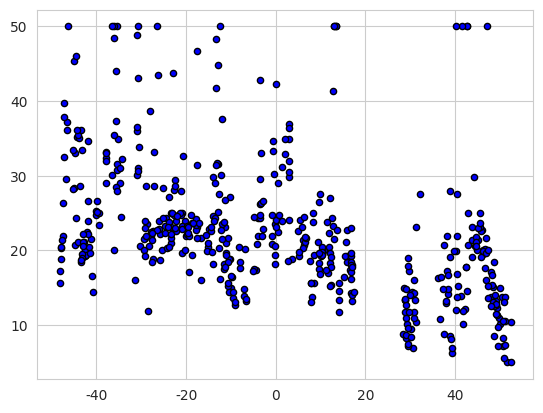

In [ ]:
### 실제 데이터 분포 시각화 :
### 압축된 좌표를 x축으로, 실제 주택 가격을 y축으로 설정하여 산점도를 그립니다.

# x축은 압축된 좌표(X_comp), y축은 실제 가격(y)으로 설정하여 점을 찍습니다.
# c='b': 점의 색상을 파란색(Blue)으로 설정합니다.
# s=20은 점 크기, edgecolors='k'는 점의 테두리를 검정색으로 설정합니다.
plt.scatter(X_comp, y, c='b', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### KNN 회귀 모델 학습 및 예측 :
### 압축된 1차원 데이터를 바탕으로 주택 가격을 예측하는 모델을 만듭니다.

# KNN 회귀 모델(KNeighborsRegressor) 객체를 생성합니다.
model = KNeighborsRegressor()

# 1차원으로 압축된 데이터(X_comp)와 실제 가격(y)을 매칭시켜 모델을 학습시킵니다.
model.fit(X_comp, y)

# 학습된 모델을 사용하여 동일한 X_comp 데이터에 대한 가격 예측값(predict)을 생성합니다.
predict = model.predict(X_comp)

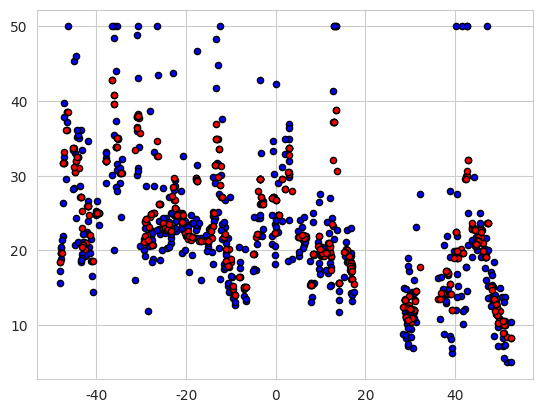

In [ ]:
### 실제값 vs 예측값 비교 시각화 :
### 모델이 실제 데이터의 추세를 얼마나 잘 따라가고 있는지 두 가지 색상의 점으로 비교합니다.

# 1. 실제 데이터 포인트: 파란색(b) 점으로 실제 주택 가격 분포를 그립니다.
plt.scatter(X_comp, y, c='b', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 2. 모델 예측 포인트: 빨간색(r) 점으로 모델이 추론한 주택 가격을 겹쳐서 그립니다.
# 파란색 점과 빨간색 점이 가깝게 위치할수록 모델의 예측 정확도가 높은 것입니다.
plt.scatter(X_comp, predict, c='r', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 캘리포니아 주택 가격 데이터

In [ ]:
### 데이터 로드

# 사이킷런에서 제공하는 캘리포니아 주택 가격 데이터셋을 불러와 변수에 저장합니다.
california = fetch_california_housing()

In [ ]:
### 데이터프레임 생성

# 독립 변수(특성) 데이터와 컬럼 이름을 사용하여 판다스 데이터프레임을 생성합니다.
california_df = pd.DataFrame(data=california.data, columns=california.feature_names)

# 데이터프레임에 예측하고자 하는 정답값(주택 가격)인 'TARGET' 열을 추가합니다.
california_df['TARGET'] = california.target

# 생성된 데이터프레임의 전체적인 구조를 확인합니다.
california_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,TARGET
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
### 학습 및 테스트 데이터 분리 :
### 모델의 성능을 공정하게 평가하기 위해 데이터를 '공부용(Train)'과 '시험용(Test)'으로 나눕니다.

# 입력 데이터(X)와 정답 데이터(y)를 각각 변수에 할당합니다.
X, y = california.data, california.target

# 전체 데이터를 학습용과 테스트용으로 8:2 비율(test_size=0.2)로 무작위 분할합니다.
# X_train: 학습용 문제, X_test: 시험용 문제, y_train: 학습용 정답, y_test: 시험용 정답
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### 분리된 데이터 확인 (학습/테스트 데이터프레임) :
### 분리된 데이터가 제대로 구성되었는지 확인하기 위해 다시 데이터프레임 형태로 만듭니다.

# 학습용 문제(X_train)를 데이터프레임으로 만들고 정답(y_train)을 붙여 확인합니다.
california_train_df = pd.DataFrame(data=X_train, columns=california.feature_names)
california_train_df['TARGET'] = y_train
california_train_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,TARGET
0,4.2283,36.0,5.610942,1.088146,748.0,2.273556,34.40,-119.71,3.268
1,2.0658,29.0,3.575439,1.014035,2070.0,3.631579,34.04,-118.31,2.146
2,4.1739,36.0,5.459627,0.985507,1385.0,2.867495,34.09,-117.71,1.587
3,2.8110,15.0,6.485014,1.186649,2459.0,3.350136,35.56,-120.29,1.421
4,2.7273,42.0,4.926641,1.003861,799.0,3.084942,38.73,-120.81,1.286
...,...,...,...,...,...,...,...,...,...
16507,3.5463,45.0,4.979899,0.944724,1179.0,2.962312,37.97,-122.33,1.308
16508,2.0461,46.0,4.909814,1.127321,1100.0,2.917772,34.07,-117.34,0.905
16509,2.9507,44.0,4.826804,1.030928,1256.0,2.589691,37.69,-122.10,1.571
16510,3.3523,25.0,4.997245,1.112948,1187.0,3.269972,34.07,-117.94,1.708


In [ ]:
### 분리된 데이터 확인 (학습/테스트 데이터프레임) :
### 분리된 데이터가 제대로 구성되었는지 확인하기 위해 다시 데이터프레임 형태로 만듭니다.

# 테스트용 문제(X_test)를 데이터프레임으로 만들고 정답(y_test)을 붙여 확인합니다.
california_test_df = pd.DataFrame(data=X_test, columns=california.feature_names)
california_test_df['TARGET'] = y_test
california_test_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,TARGET
0,2.2500,17.0,3.860377,1.054717,1585.0,2.990566,32.58,-117.10,1.32800
1,2.5402,42.0,6.250000,1.151042,647.0,3.369792,37.52,-120.89,1.57500
2,5.8325,18.0,6.351876,1.056921,1971.0,2.549806,36.96,-121.88,3.08800
3,2.7083,52.0,4.952381,0.974603,757.0,2.403175,32.72,-117.13,1.99100
4,2.4459,17.0,3.824879,1.039855,2098.0,2.533816,32.97,-117.10,0.85800
...,...,...,...,...,...,...,...,...,...
4123,10.3048,36.0,8.134921,1.190476,316.0,2.507937,33.61,-117.92,5.00001
4124,4.8693,45.0,5.986755,1.043046,800.0,2.649007,33.83,-118.17,2.77700
4125,3.8750,31.0,4.416667,0.880952,208.0,2.476190,38.73,-122.00,1.37500
4126,4.3500,36.0,5.962343,1.025105,573.0,2.397490,37.95,-122.32,1.85000


In [ ]:
### 데이터 표준화 (Scaling) :
### K-최근접 이웃(KNN) 알고리즘은 거리 기반 모델이므로,
### 단위가 다른 변수들의 범위를 맞춰주는 작업이 필수적입니다.

# 평균을 0, 표준편차를 1로 만드는 표준화 스케일러 객체를 생성합니다.
scaler = StandardScaler()

# 학습 데이터의 통계량(평균, 표준편차)을 계산함과 동시에 데이터를 변환합니다.
X_train_scale = scaler.fit_transform(X_train)

# 학습 데이터에서 얻은 통계량을 그대로 사용하여 테스트 데이터를 변환합니다. (중요: fit 하지 않음)
X_test_scale = scaler.transform(X_test)

In [ ]:
### 스케일링 전 모델 학습 :
### 데이터 전처리가 성능에 미치는 영향을 비교하기 위해 원본 데이터로 먼저 학습해 봅니다.

# K-최근접 이웃 회귀 모델 객체를 생성합니다.
model = KNeighborsRegressor()

# 원본(스케일링 전) 학습 데이터를 사용하여 모델을 학습시킵니다.
model.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
### 스케일링 전 모델 평가

# 학습된 모델의 결정계수(R^2) 점수를 출력합니다. (1에 가까울수록 성능이 좋음)
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.45216460877320164
평가 데이터 점수: 0.15666123983674396


In [ ]:
### 스케일링 후 모델 학습

# 모델 객체를 다시 생성(초기화)합니다.
model = KNeighborsRegressor()

# 스케일링이 완료된 학습 데이터를 사용하여 모델을 다시 학습시킵니다.
model.fit(X_train_scale, y_train)

KNeighborsRegressor()

In [ ]:
### 스케일링 후 모델 평가 :
### 표준화된 데이터를 사용하여 성능이 얼마나 개선되었는지 확인합니다.

# 스케일링된 데이터를 기준으로 점수를 출력합니다. 보통 전처리 후 성능이 올라갑니다.
print("학습 데이터 점수: {}".format(model.score(X_train_scale, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test_scale, y_test)))

학습 데이터 점수: 0.7959000006498659
평가 데이터 점수: 0.6749301927526763


In [ ]:
### 파이프라인 생성 (Pipeline Construction) :
### 데이터 전처리와 모델 학습을 하나의 체인으로 묶는 과정

# StandardScaler와 KNeighborsRegressor를 순서대로 실행하는 파이프라인을 생성합니다.
# 이렇게 묶어두면 데이터를 넣었을 때 자동으로 스케일링 후 모델 학습까지 진행됩니다.
estimator = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor()
)

In [ ]:
### 교차 검증 (Cross Validation) :
### 데이터를 여러 조각으로 나누어 모델의 일반화 성능을 더 정확하게 측정합니다.

# 생성한 파이프라인(estimator)을 사용하여 교차 검증을 수행합니다.
cross_validate(
    estimator=estimator,           # 검증할 모델(파이프라인)
    X=X, y=y,                      # 전체 데이터와 정답
    cv=5,                          # 데이터를 5등분하여 5번 검증 (K-Fold)
    n_jobs=multiprocessing.cpu_count(), # 컴퓨터의 모든 CPU 코어를 사용하여 병렬 처리
    verbose=True                   # 진행 과정을 화면에 출력
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:    1.7s finished


{'fit_time': array([0.04320216, 0.04422092, 0.04241896, 0.04256845, 0.04176378]),
 'score_time': array([0.67945862, 0.56801081, 0.55049324, 0.68619013, 0.47801661]),
 'test_score': array([0.47879396, 0.4760079 , 0.57624554, 0.50259828, 0.57228584])}

cross_validate한 결과 좋게 나옴.

In [ ]:
### 파이프라인 및 파라미터 그리드 설정 :
### 그리드 서치(GridSearch)를 위해 파이프라인에 이름을 붙이고, 테스트할 후보군을 정의합니다.

# 파이프라인을 생성하며 각 단계에 'scaler', 'model'이라는 이름을 부여합니다.
pipe = Pipeline(
    [('scaler', StandardScaler()),
     ('model', KNeighborsRegressor())]
)

In [ ]:
### 파이프라인 및 파라미터 그리드 설정 :
### 그리드 서치(GridSearch)를 위해 파이프라인에 이름을 붙이고, 테스트할 후보군을 정의합니다.

# 모델의 성능을 결정하는 '하이퍼파라미터' 조합을 설정합니다.
# 'model__속성명' 형식은 파이프라인 내 'model' 단계의 속성을 의미합니다.
param_grid = [{
    'model__n_neighbors': [3, 5, 7],           # 이웃의 수 후보
    'model__weights': ['uniform', 'distance'], # 거리 가중치 부여 방식
    'model__algorithm': ['ball_tree', 'kd_tree', 'brute'] # 이웃 탐색 알고리즘
}]

In [ ]:
### 그리드 서치 수행 :
### 수많은 조합 중 가장 성능이 좋은 설정을 자동으로 찾아냅니다.

# 하이퍼파라미터 조합을 전수 조사하는 GridSearchCV 객체를 생성합니다.
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    n_jobs=multiprocessing.cpu_count(),
    verbose=True
)

In [ ]:
### 그리드 서치 수행 및 학습

# 모든 조합에 대해 학습을 진행하여 최적의 파라미터를 찾습니다.
gs.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsRegressor())]),
             n_jobs=2,
             param_grid=[{'model__algorithm': ['ball_tree', 'kd_tree', 'brute'],
                          'model__n_neighbors': [3, 5, 7],
                          'model__weights': ['uniform', 'distance']}],
             verbose=True)

In [ ]:
### 그리드 서치 결과 확인

# 가장 성능이 좋았던 모델의 설정값(최적의 파라미터 조합)을 보여줍니다.
gs.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsRegressor(algorithm='brute', n_neighbors=7,
                                     weights='distance'))])

In [ ]:
### 그리드 서치 결과 확인

# 가장 높게 나온 성능 점수(R^2)를 출력합니다.
print('GridSearchCV best score: {}'.format(gs.best_score_))

GridSearchCV best score: 0.5376515274379834


In [ ]:
### t-SNE를 이용한 차원 축소 및 시각화 준비 :
### 고차원 데이터를 1차원으로 줄여서 그래프로 그릴 수 있게 만듭니다.

# t-SNE 알고리즘을 사용하여 복잡한 독립 변수(X)들을 1차원(n_components=1)으로 압축합니다.
# 시각화를 위해 고차원의 특징들을 최대한 보존하며 저차원으로 변환하는 과정입니다.
tsne = TSNE(n_components=1)
X_comp = tsne.fit_transform(X)

In [ ]:
### t-SNE를 이용한 차원 축소 및 시각화 준비 :
### 고차원 데이터를 1차원으로 줄여서 그래프로 그릴 수 있게 만듭니다.

# 변환된 데이터와 정답(Target)을 합쳐 데이터프레임을 생성하여 구조를 확인합니다.
boston_comp_df = pd.DataFrame(data=X_comp)
boston_comp_df['Target'] = y
boston_comp_df

,0,Target
0,-116.769104,4.526
1,89.227425,3.585
2,-98.721977,3.521
3,-90.616730,3.413
4,-89.922958,3.422
...,...,...
20635,-46.852879,0.781
20636,-113.767998,0.771
20637,-23.147985,0.923
20638,-61.939793,0.847


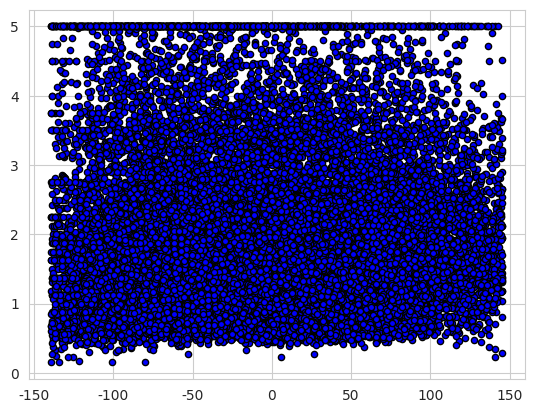

In [ ]:
### 실제 데이터 분포 시각화 :
### 데이터가 어떤 형태를 띠고 있는지 산점도로 확인합니다.

# 압축된 데이터(X_comp)를 가로축, 실제 주택 가격(y)을 세로축으로 하여 파란색(c='b') 점으로 그립니다.
plt.scatter(X_comp, y, c='b', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

In [ ]:
### 차원 축소 데이터 기반 학습 및 예측 :
### 차원이 축소된 데이터를 바탕으로 다시 학습을 진행합니다

# 모델 객체를 생성하고, t-SNE로 압축된 데이터(X_comp)를 사용하여 학습합니다.
model = KNeighborsRegressor()
model.fit(X_comp, y)

# 학습된 모델을 사용하여 다시 예측값(predict)을 생성합니다.
predict = model.predict(X_comp)

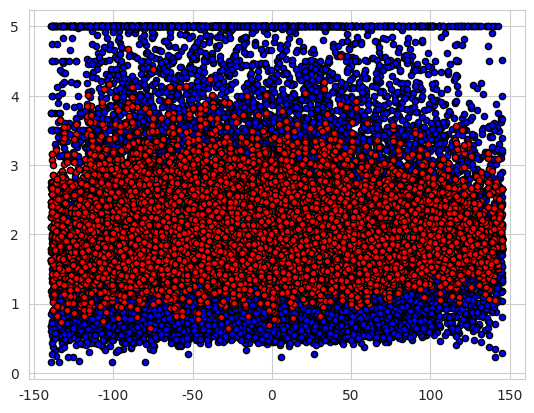

In [ ]:
### 실제값 vs 예측값 비교 시각화 :
### 모델이 실제 데이터를 얼마나 잘 따라가는지 한눈에 비교합니다.

# 실제 정답값(y)을 파란색(c='b') 점으로 그립니다.
plt.scatter(X_comp, y, c='b', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

# 모델이 예측한 값(predict)을 빨간색(c='r') 점으로 겹쳐서 그립니다.
# 파란 점과 빨간 점이 얼마나 근접해 있는지에 따라 모델의 성능을 시각적으로 판단할 수 있습니다.
plt.scatter(X_comp, predict, c='r', cmap=plt.cm.coolwarm, s=20, edgecolors='k');

참고) https://scikit-learn.org/stable/modules/model_evaluation.html